# Spin Coherence Time Optimization by Mapping Method

A sufficiently long **Spin Coherence Time (SCT)** is a fundamental requirement for precision measurements of the electric dipole moment (EDM) of charged particles in storage rings. SCT optimization is performed using **three sextupole families** that suppress second-order effects arising from emittance and momentum spread. These sextupoles are placed at the maxima of the beta functions in both planes and in regions with significant horizontal dispersion.

This notebook examines the capability of the **mapping method** to simultaneously suppress spin decoherence and achieve **zero chromaticity** in both transverse planes in:

| Class | Structures (first stage) |
|-------|--------------------------|
| Magnetic | `magnetic_2`, `magnetic_3` |
| Electrostatic | `electrostatic` |
| Combined (Wien filter) | `Nuclotron_8`, `Nuclotron_16` |

A **separate block** at the end covers the full magnetic series `magnetic_3`…`magnetic_8` (Twiss, layout, $\Delta\nu_s$ analysis).

**Measured quantity:** $\Delta\nu_s = \nu_{s,\mathrm{probe}} - \nu_{s,\mathrm{ref}}$.

**Fringe modes:** FR0 (no fringe, $5^3$ grid) and FR3 (fringe on, $3^3$ grid).

Regenerate mapping data with:
```bash
python COSY/analysis/run_mapping.py --pre --presentation --mode both
```


In [29]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display
from matplotlib.ticker import ScalarFormatter

# Resolve analysis dir regardless of Jupyter cwd
_cwd = Path.cwd()
if (_cwd / "map_lat_lib.py").is_file():
    ANALYSIS_DIR = _cwd
elif (_cwd / "COSY" / "analysis" / "map_lat_lib.py").is_file():
    ANALYSIS_DIR = _cwd / "COSY" / "analysis"
else:
    ANALYSIS_DIR = Path(r"C:/GIT_REPOS/SCT/COSY/analysis")
sys.path.insert(0, str(ANALYSIS_DIR))

from map_lat_lib import (
    DEFAULT_ROOT,
    PRESENTATION_LATTICES,
    PANEL_CHROM_LABELS,
    PANEL_COLORS,
    PANEL_CONSTRAINTS,
    PLANE_NAMES,
    STEPS_DEFAULT,
    build_lattice_models,
    chrom_range_report,
    compute_panel_curves,
    get_data,
    get_dual_model,
    plot_verify_chrom_to_spin,
    print_mapping_audit,
    standard_chrom_ranges,
    verify_chrom_model,
    verify_chrom_to_spin_link,
    zero_chrom_working_point,
)
from plot_magnetic_map import plot_lattice
from plotter_lattice import default_lattice_db, plot_and_save_lattice

plt.rcParams.update({"font.size": 10, "axes.grid": True})

lattices = list(PRESENTATION_LATTICES)
MODES = ["FR0", "FR3"]
root_path = DEFAULT_ROOT
print("lattices:", lattices)
print("dat root:", root_path)


lattices: ['magnetic_2', 'magnetic_3', 'electrostatic', 'Nuclotron_8', 'Nuclotron_16']
dat root: C:\GIT_REPOS\SCT\COSY\src\dat


## Lattice Twiss and Layout

Optics and floor plans use the same engine as `Plotter.ipynb` (`plotter_lattice.py`): $\beta_x$, $\beta_y$, $D_x$ versus path length $s$, element strip, and ring survey with magnetic / electrostatic / Wien-filter colouring.


   [dir] Reading data from: C:\GIT_REPOS\SCT\COSY\src\dat\magnetic_2
      OK BETAX: loaded 85 points
      OK BETAY: loaded 85 points
      OK DISPX: loaded 85 points
OK: C:\GIT_REPOS\SCT\COSY\src\dat\magnetic_2\magnetic_2_twiss.png
OK: C:\GIT_REPOS\SCT\COSY\src\dat\magnetic_2\magnetic_2_layout.png
magnetic_2


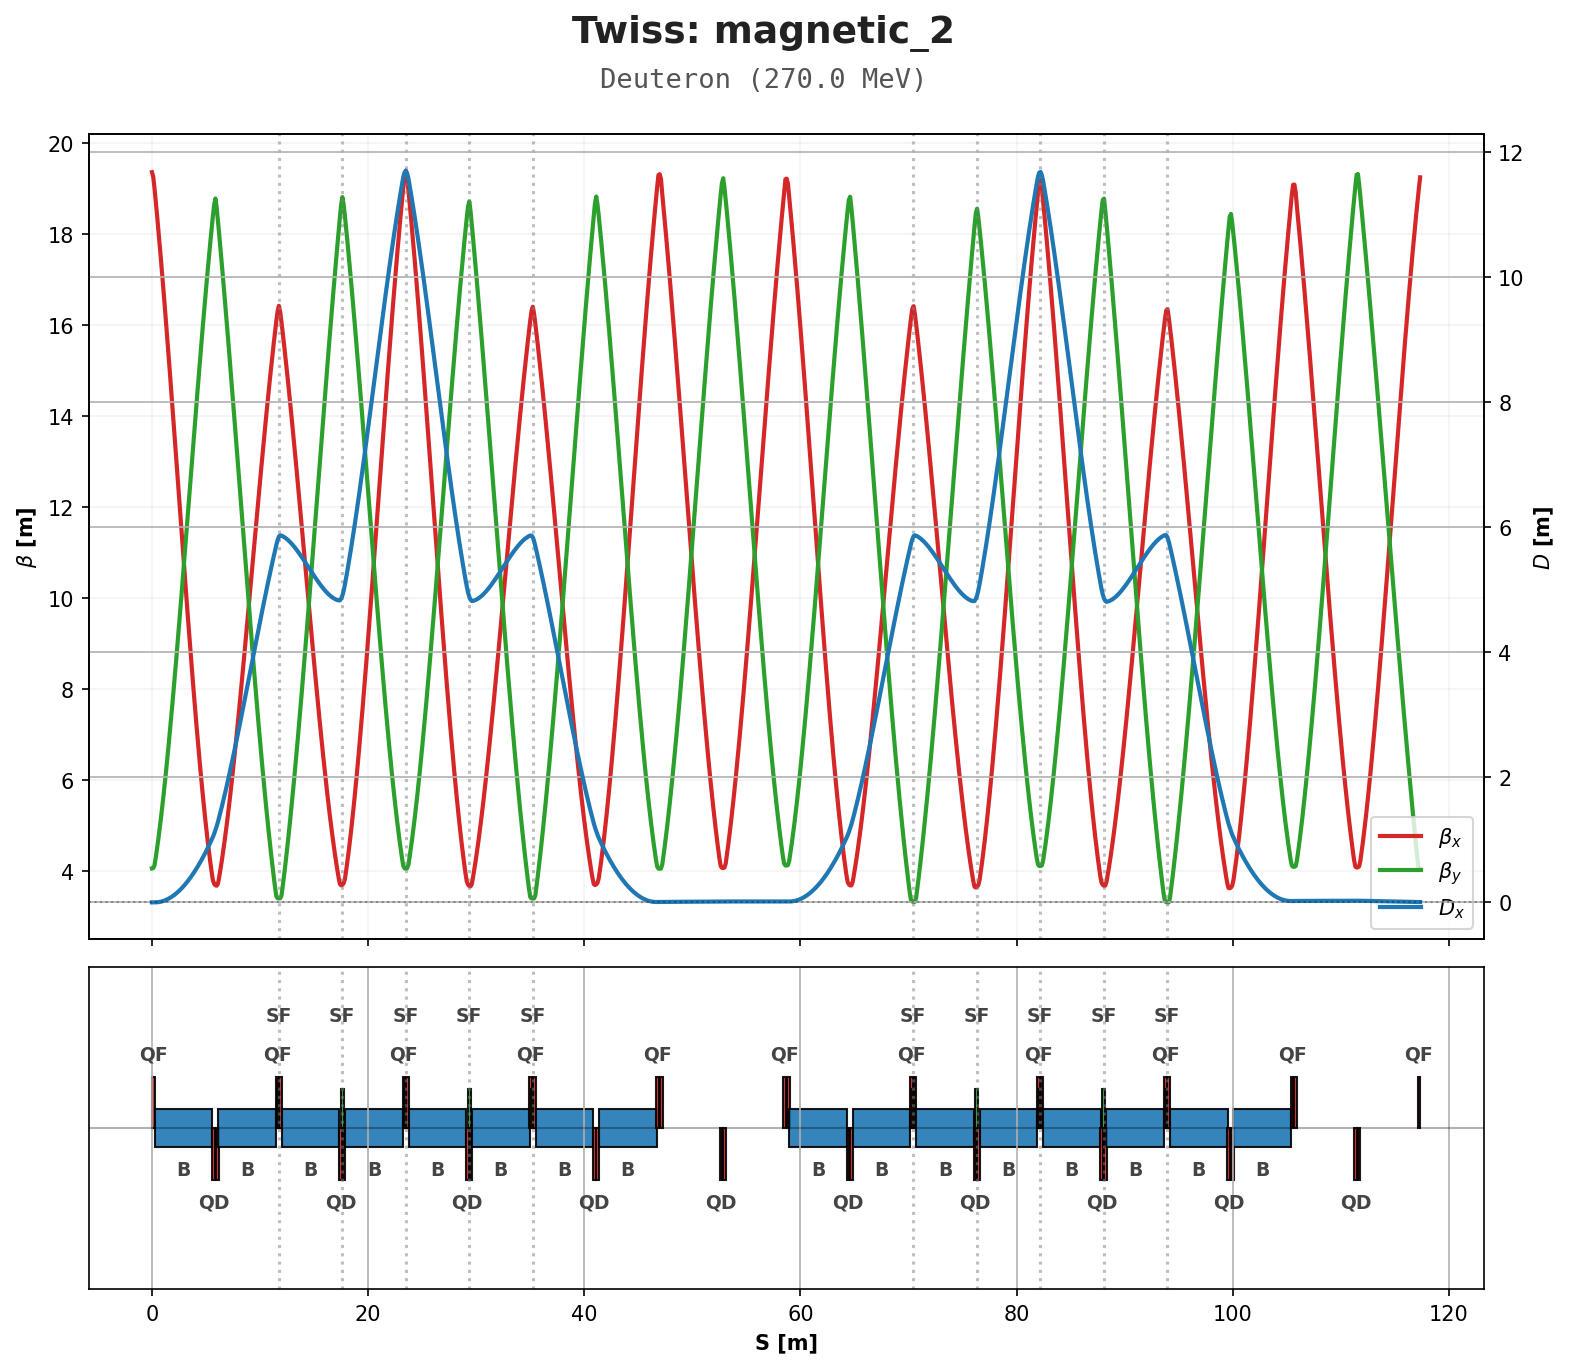

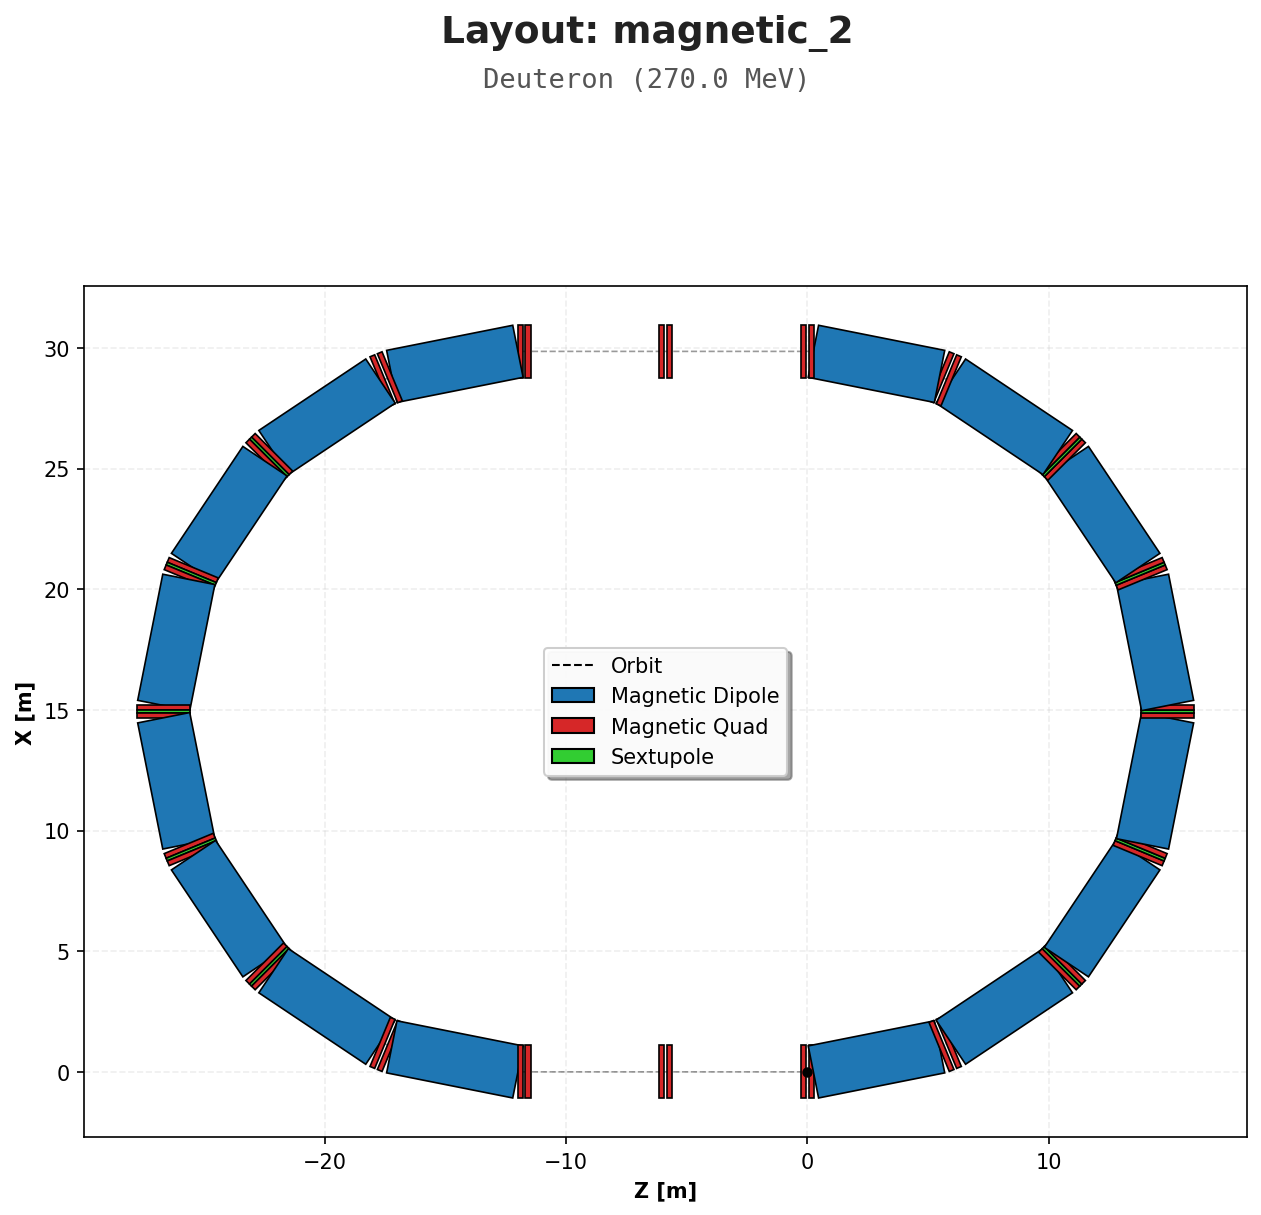

   [dir] Reading data from: C:\GIT_REPOS\SCT\COSY\src\dat\magnetic_3
      OK BETAX: loaded 127 points
      OK BETAY: loaded 127 points
      OK DISPX: loaded 127 points
OK: C:\GIT_REPOS\SCT\COSY\src\dat\magnetic_3\magnetic_3_twiss.png
OK: C:\GIT_REPOS\SCT\COSY\src\dat\magnetic_3\magnetic_3_layout.png
magnetic_3


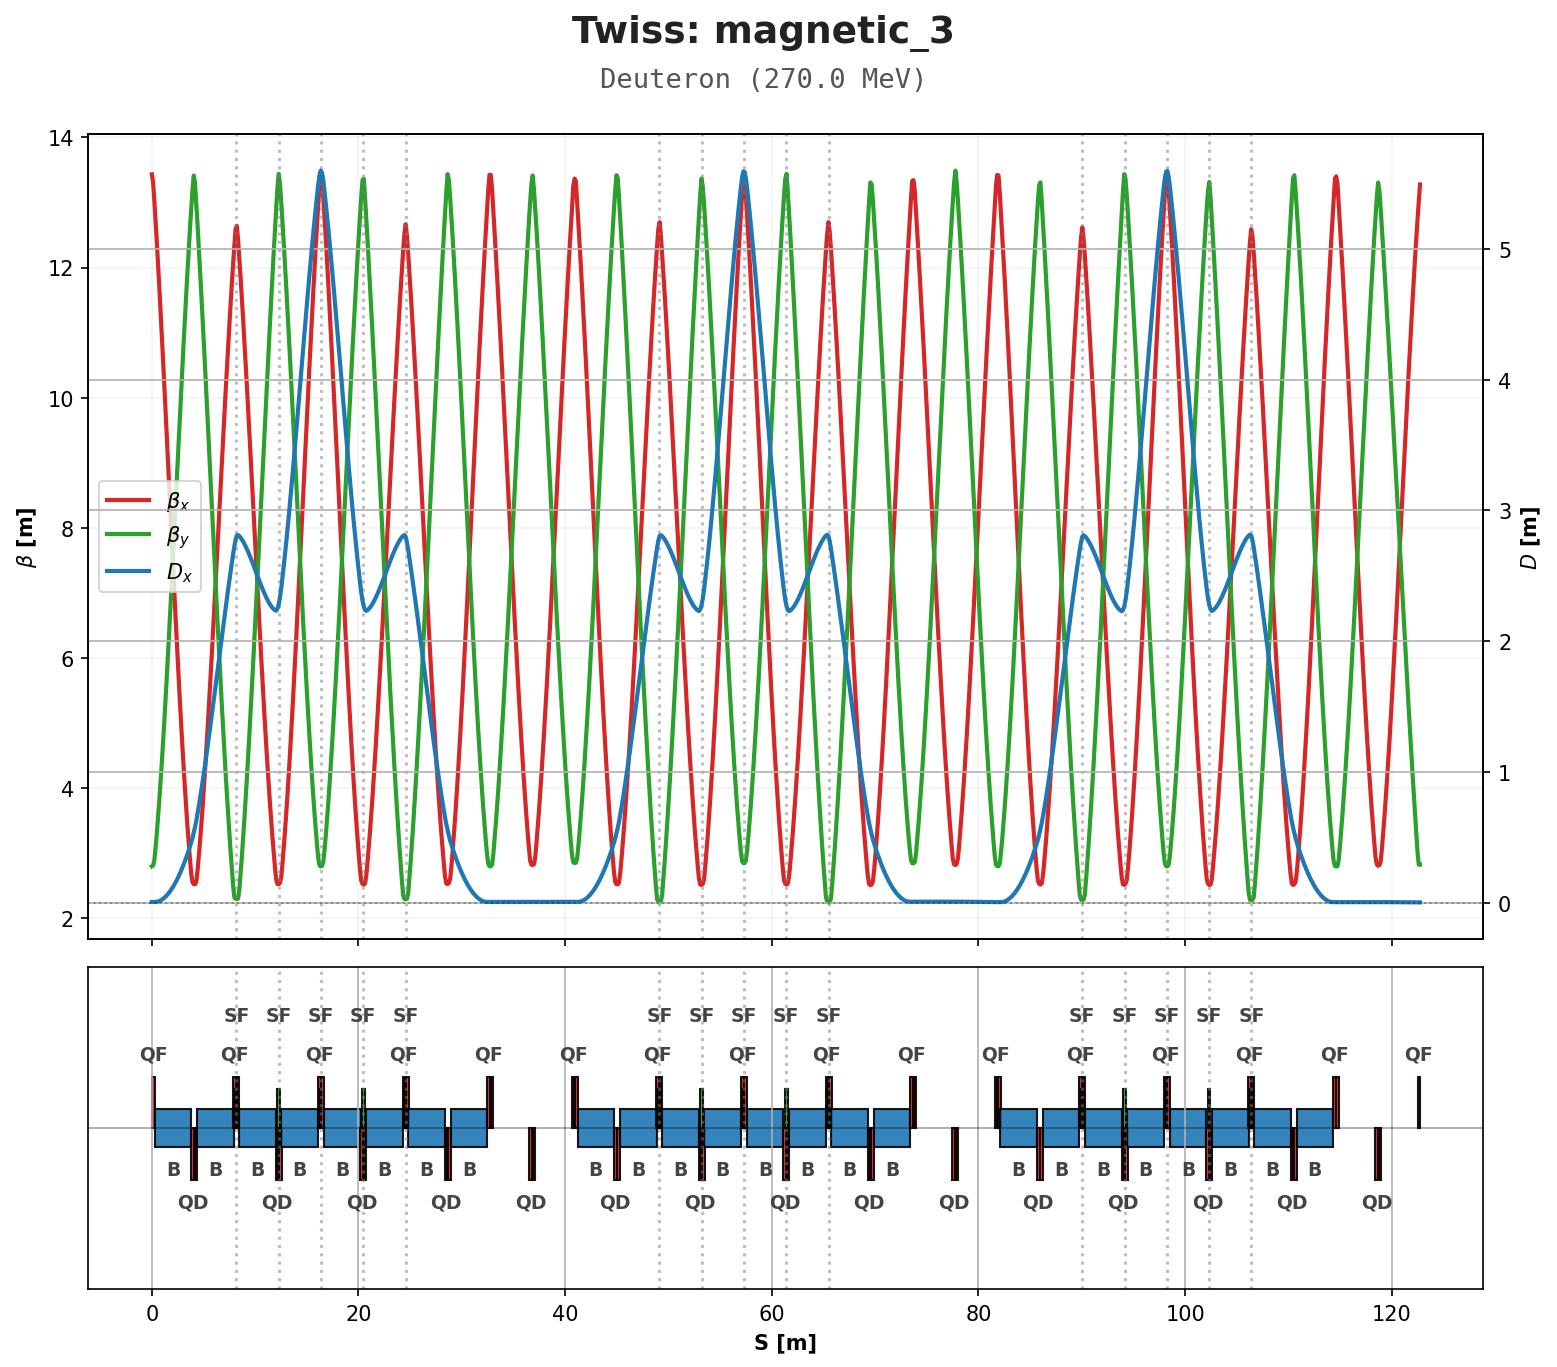

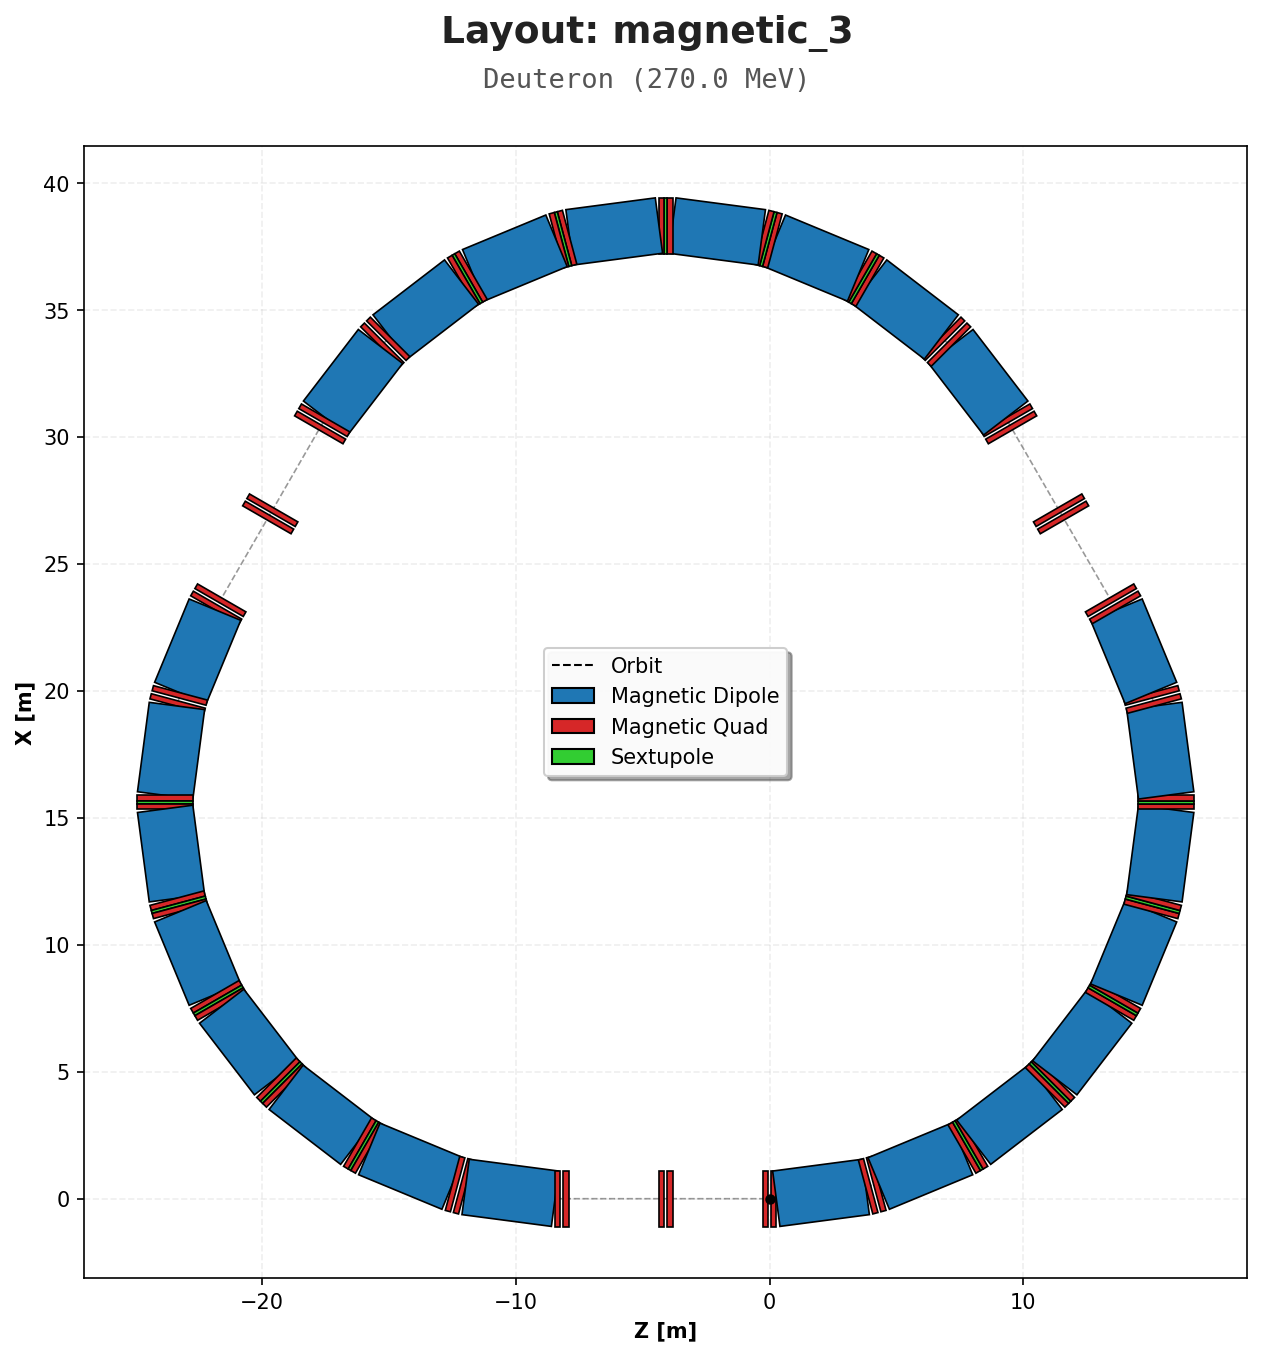

   [dir] Reading data from: C:\GIT_REPOS\SCT\COSY\src\dat\electrostatic
      OK BETAX: loaded 58 points
      OK BETAY: loaded 58 points
      OK DISPX: loaded 58 points
OK: C:\GIT_REPOS\SCT\COSY\src\dat\electrostatic\electrostatic_twiss.png
OK: C:\GIT_REPOS\SCT\COSY\src\dat\electrostatic\electrostatic_layout.png
electrostatic


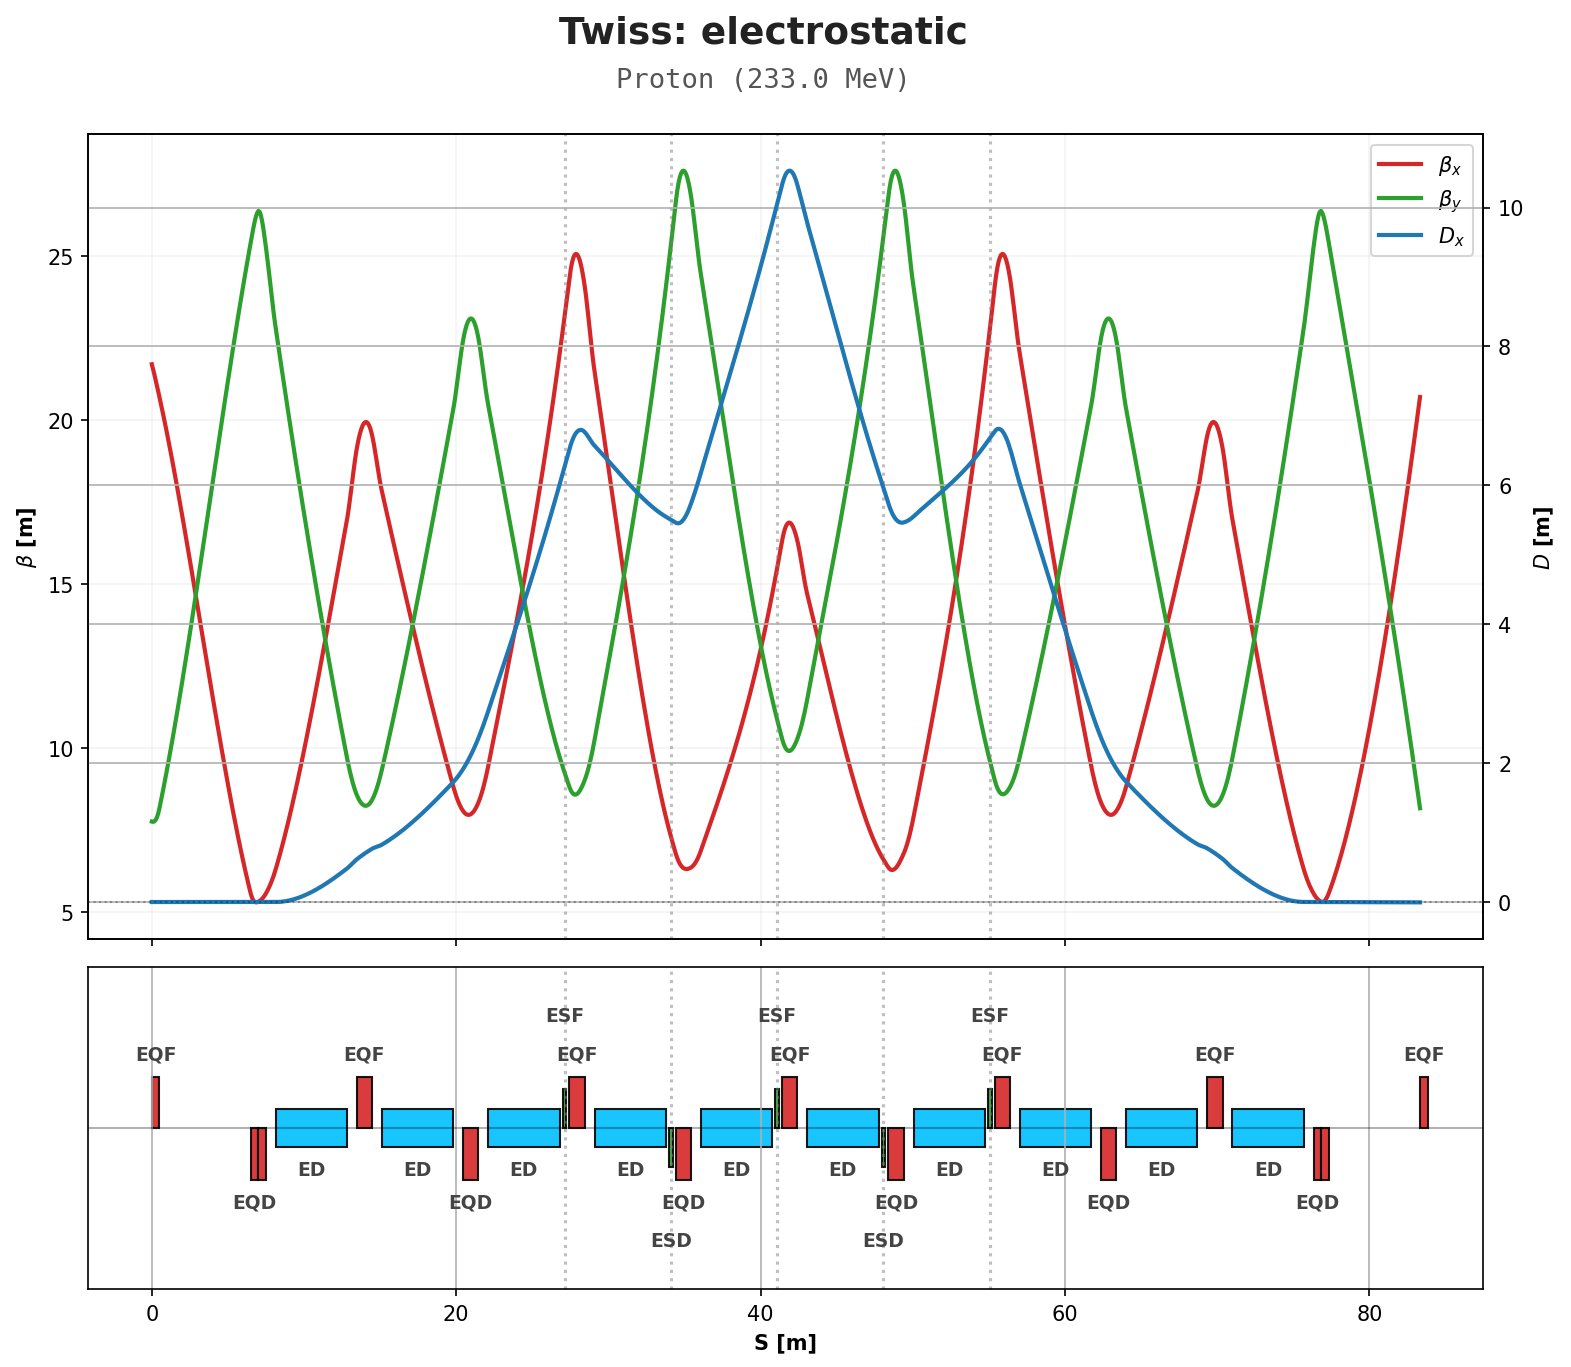

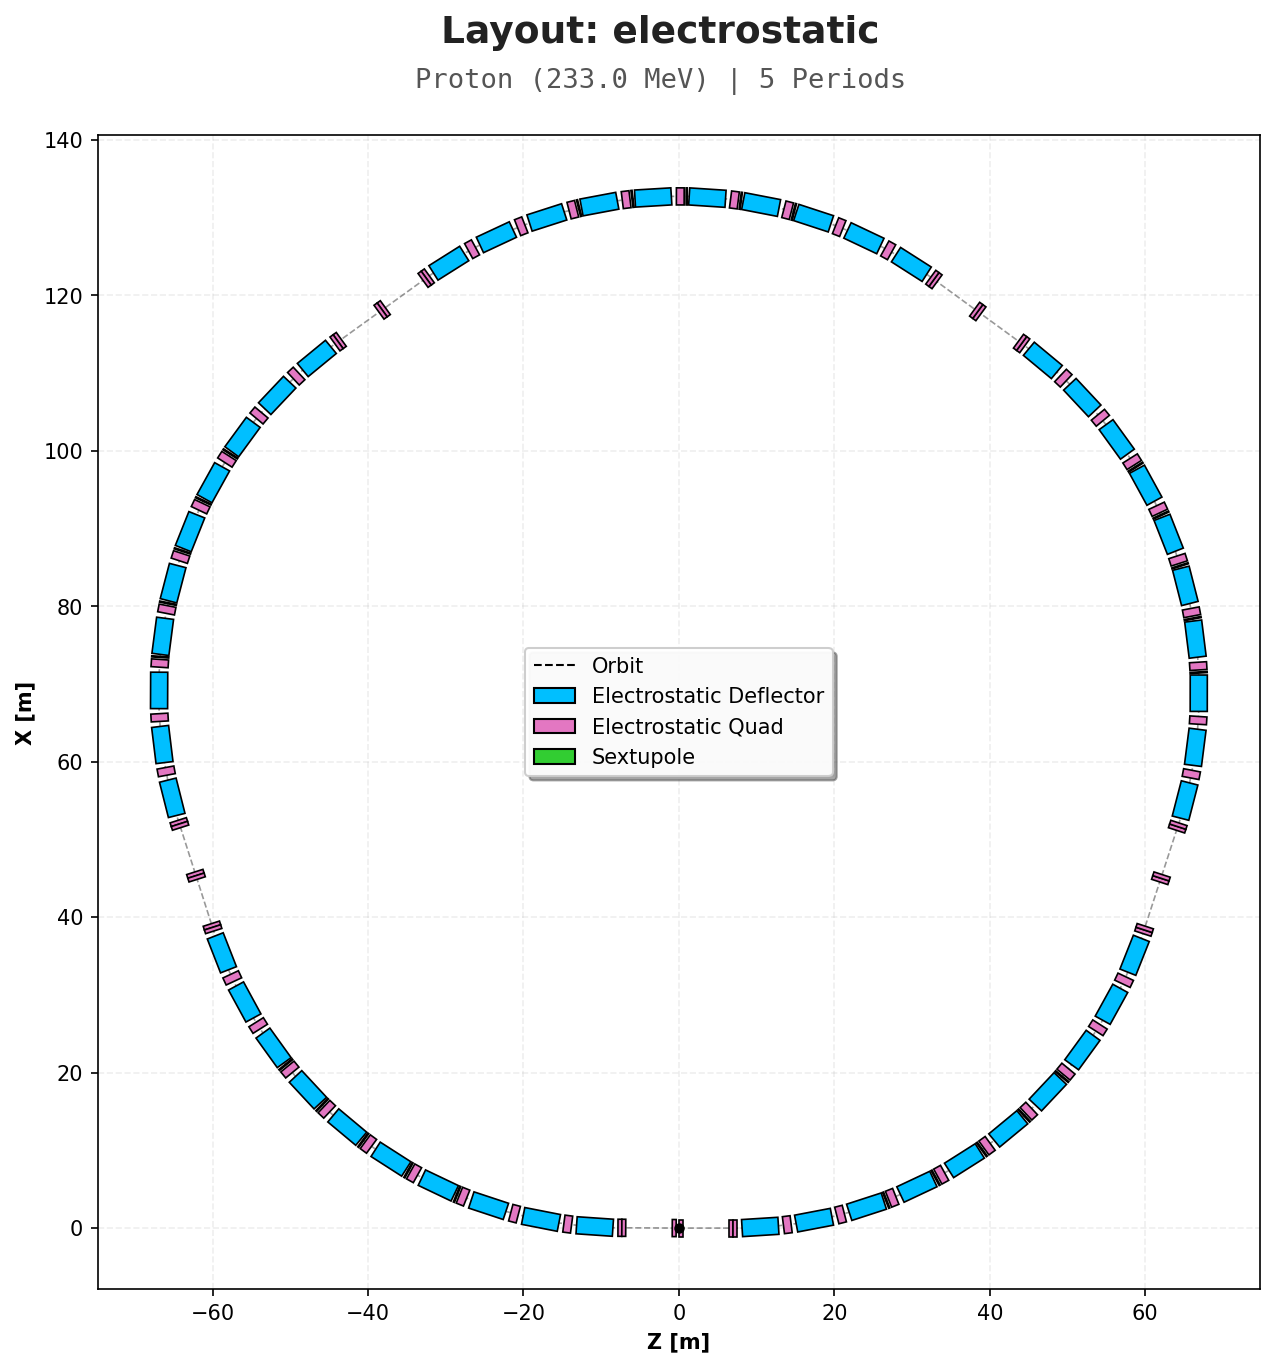

   [dir] Reading data from: C:\GIT_REPOS\SCT\COSY\src\dat\Nuclotron_8
      OK BETAX: loaded 46 points
      OK BETAY: loaded 46 points
      OK DISPX: loaded 46 points
OK: C:\GIT_REPOS\SCT\COSY\src\dat\Nuclotron_8\Nuclotron_8_twiss.png
OK: C:\GIT_REPOS\SCT\COSY\src\dat\Nuclotron_8\Nuclotron_8_layout.png
Nuclotron_8


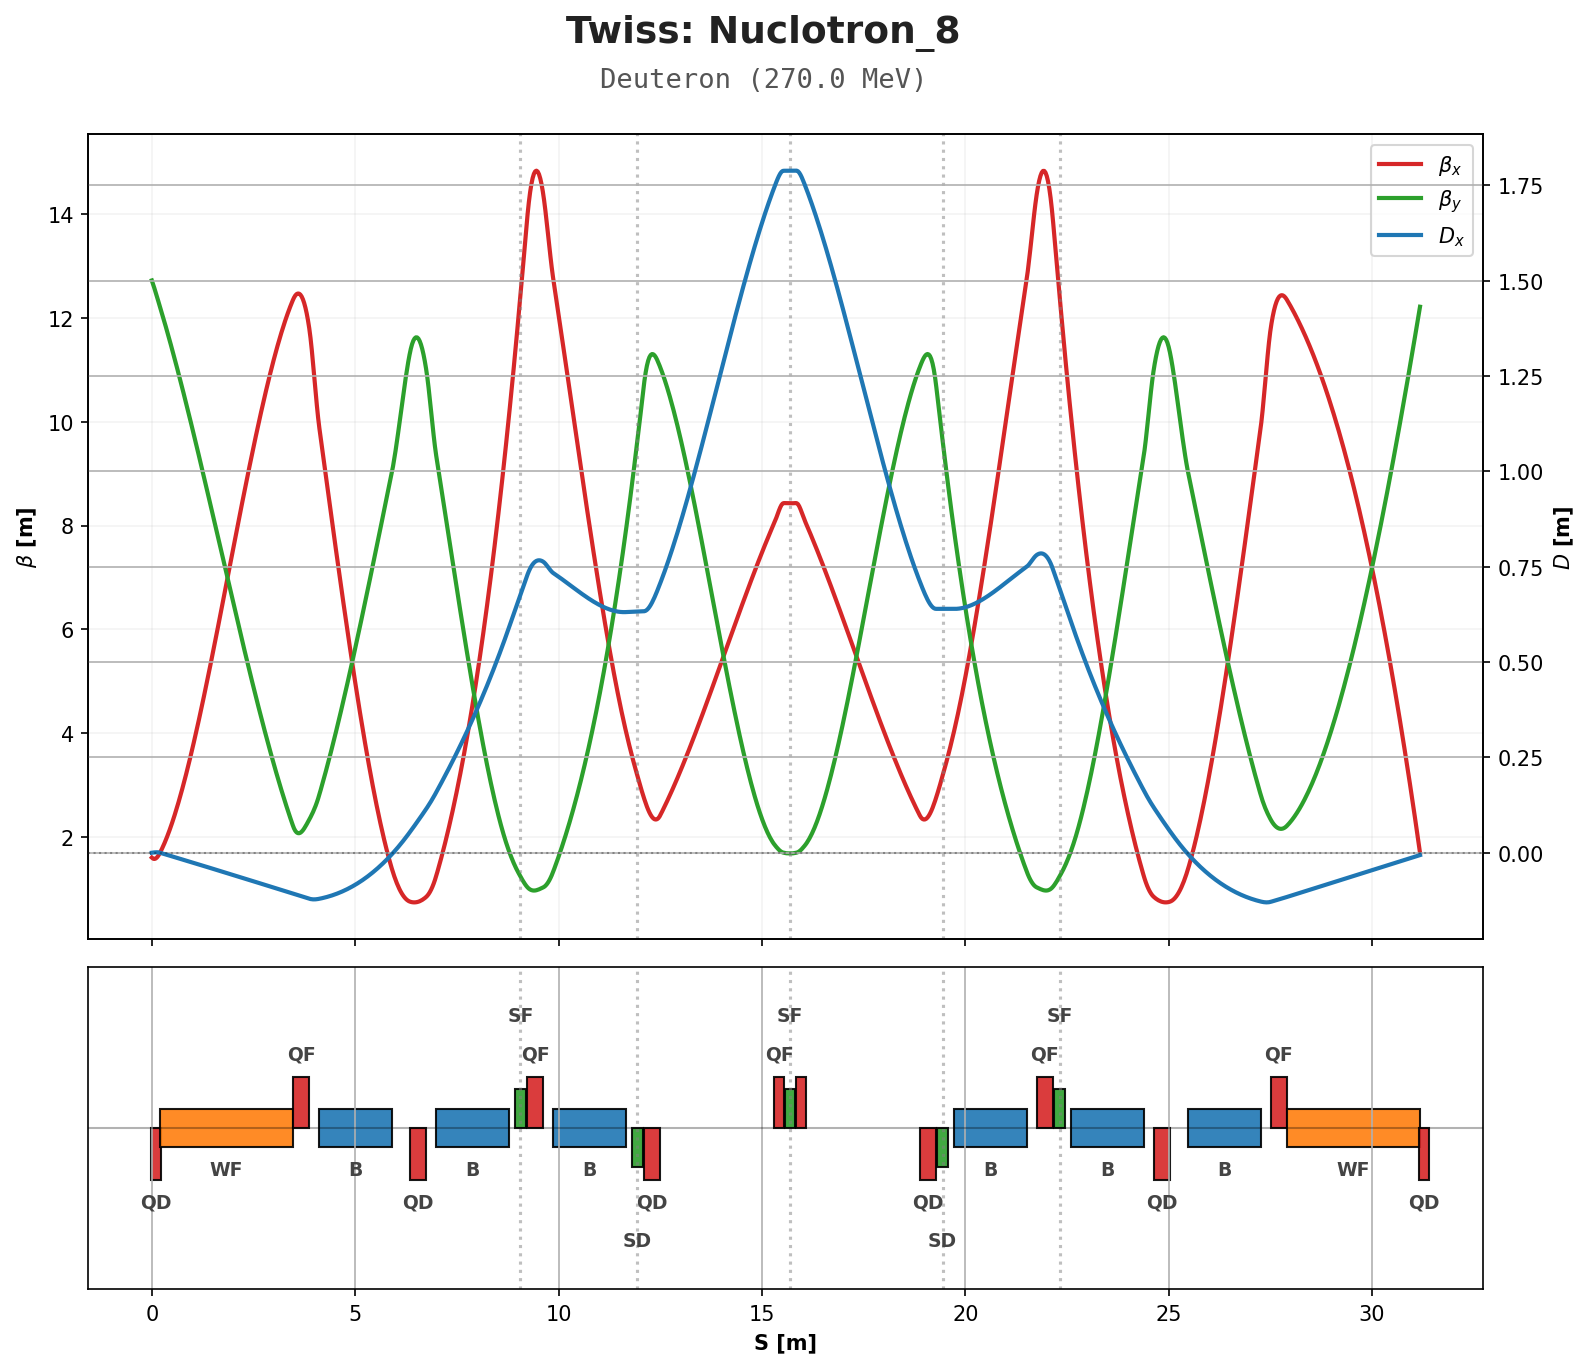

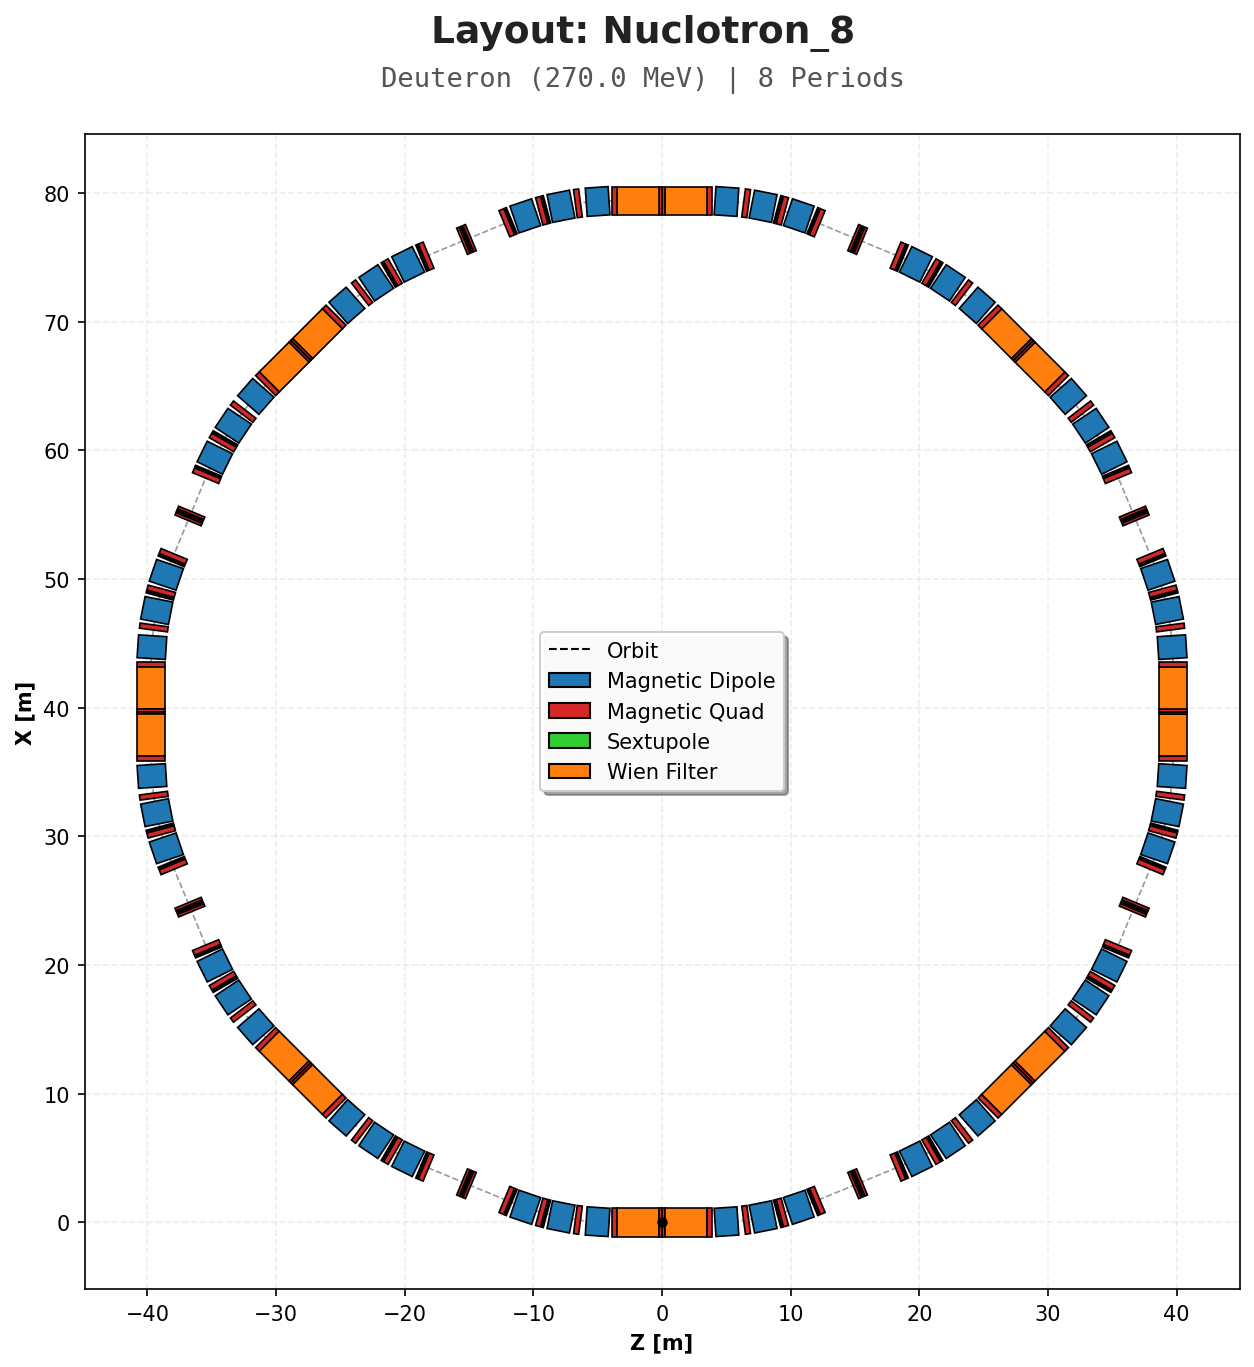

   [dir] Reading data from: C:\GIT_REPOS\SCT\COSY\src\dat\Nuclotron_16
      OK BETAX: loaded 48 points
      OK BETAY: loaded 48 points
      OK DISPX: loaded 48 points
OK: C:\GIT_REPOS\SCT\COSY\src\dat\Nuclotron_16\Nuclotron_16_twiss.png
OK: C:\GIT_REPOS\SCT\COSY\src\dat\Nuclotron_16\Nuclotron_16_layout.png
Nuclotron_16


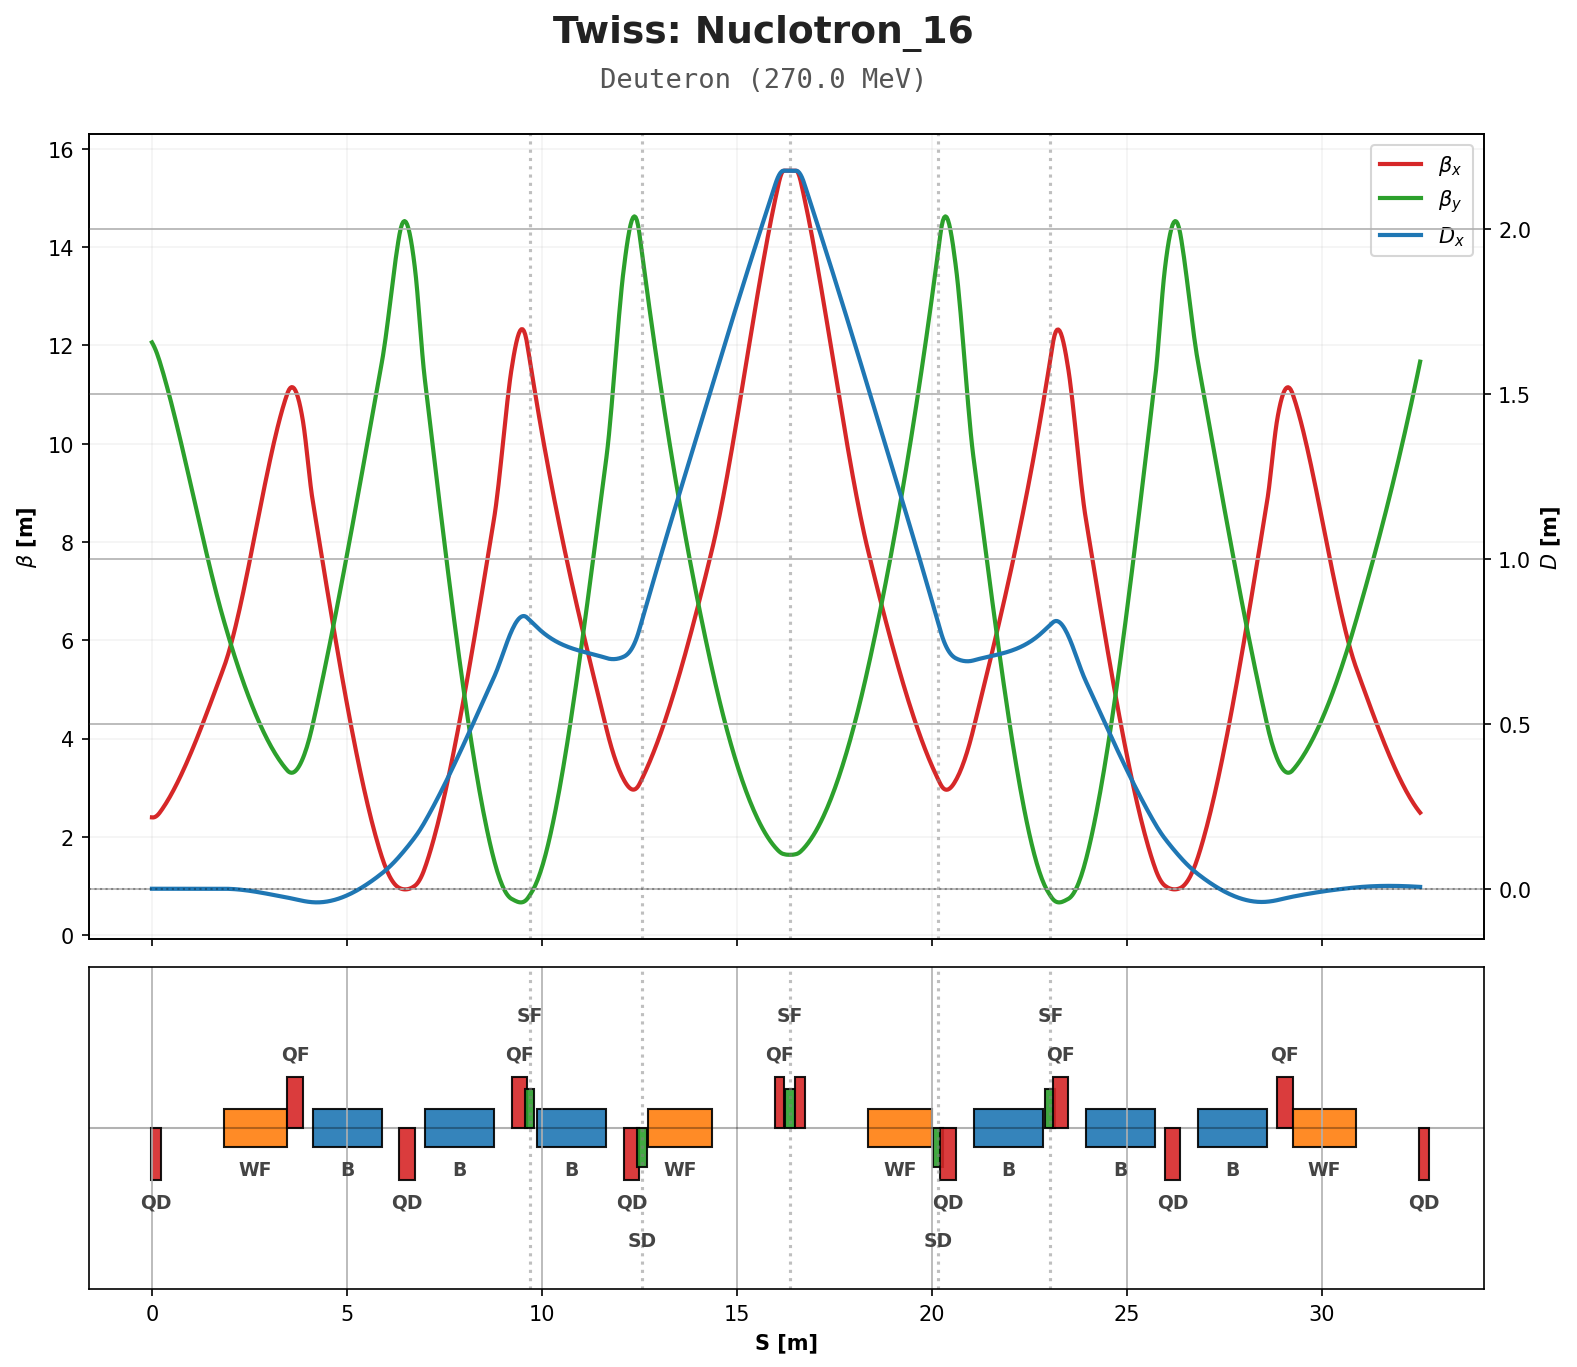

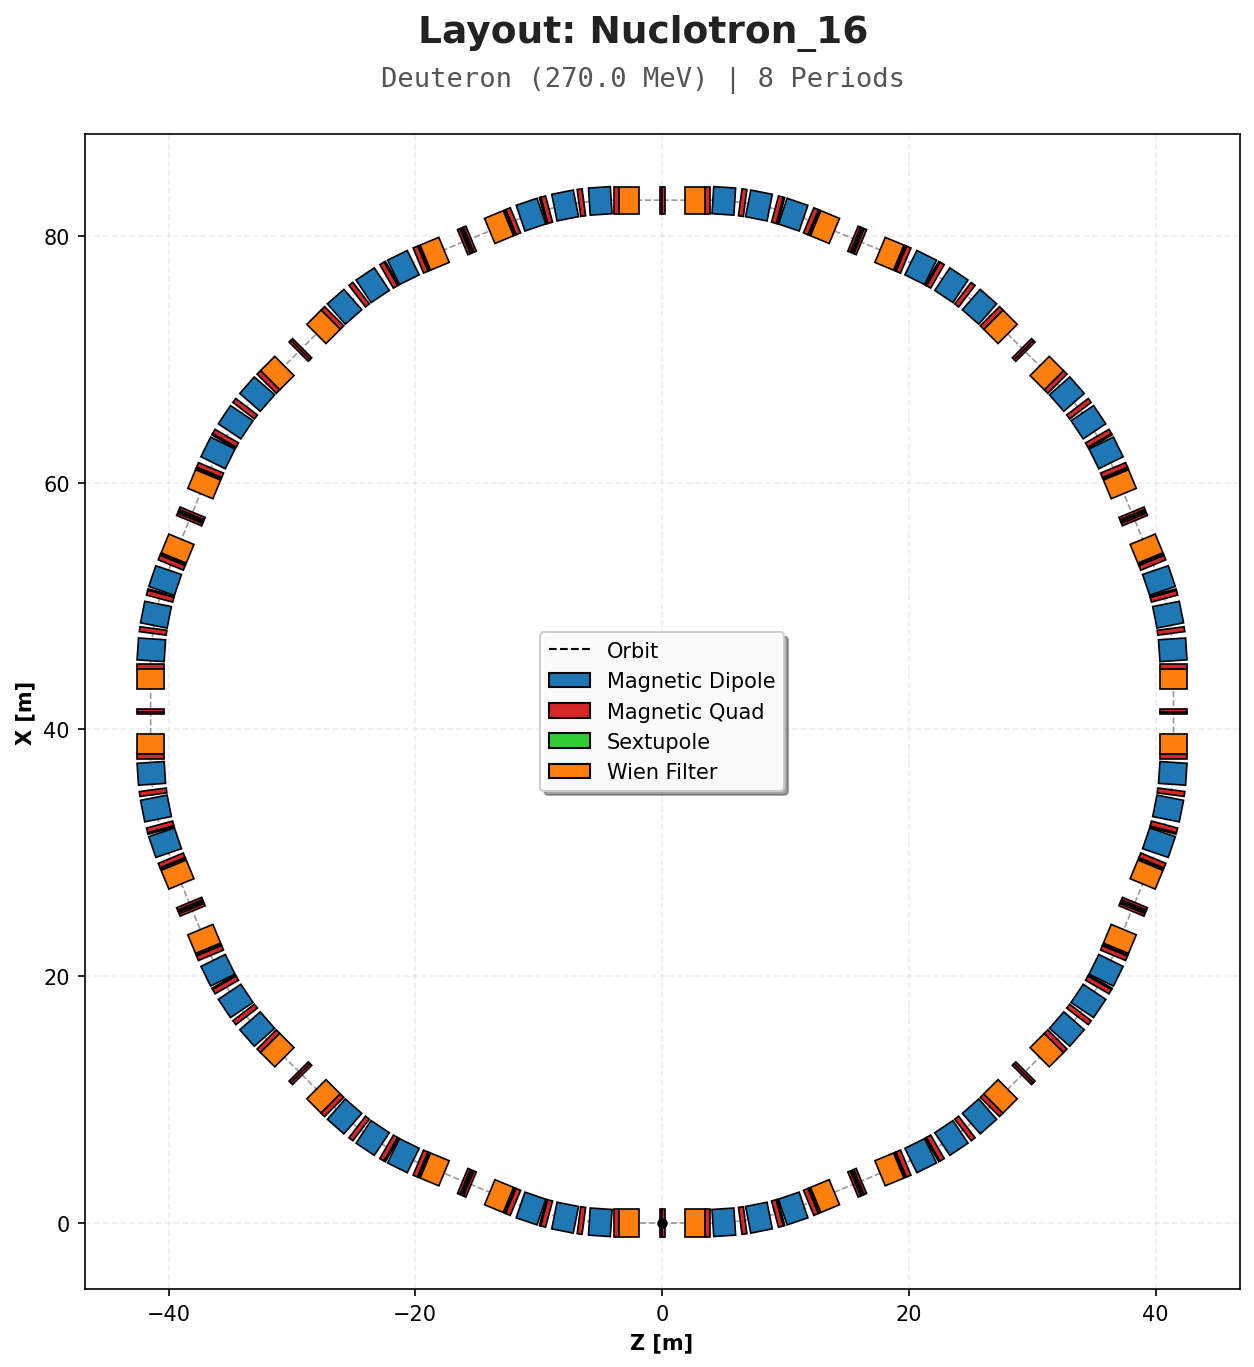

In [30]:
# Generate (or refresh) Twiss + layout PNGs for each presentation lattice
db = default_lattice_db()
for lat in lattices:
    twiss_png, layout_png = plot_and_save_lattice(lat, config=db[lat], show=False)
    print(lat)
    display(Image(filename=str(twiss_png)))
    display(Image(filename=str(layout_png)))


## Data Structure and Path Configuration

### 1. Root Directory and Lattice List
* **Root Path**: `COSY/src/dat/<lattice>/` contains COSY-INFINITY mapping outputs.
* **Lattice Structures**: magnetic (`magnetic_2`, `magnetic_3`), purely electrostatic (`electrostatic`), and combined Wien-filter lattices (`Nuclotron_8`, `Nuclotron_16`).

### 2. Input Files and Multi-Particle Schema
Three primary data files per lattice and fringe mode:

* **`integrals_{FR0|FR3}.dat`**: Sextupole families (`SGx1`, `SGx2`, `SGy1`) and observables $\xi_x$, $\xi_y$, $\eta_1$.
* **`particle_spin_tune_{mode}.dat` (P0)**: Spin response for three probes with **nominal** offsets (1 mm / 0.1 mm).
* **`particle_spin_tune_1_{mode}.dat` (P1)**: Same planes with **increased** amplitudes (2 mm / 0.5 mm).

### 3. Simulation Ranges and Plane Decoupling
* Horizontal ($\xi_x$): $[-10, 10]$
* Vertical ($\xi_y$): $[-10, 10]$
* Longitudinal ($\eta_1$): $[-1, 1]$

Decoupling constraints:
* $x$-plane: $\xi_y = 0$, $\eta_1 = 0$
* $y$-plane: $\xi_x = 0$, $\eta_1 = 0$
* $z$-plane: $\xi_x = 0$, $\xi_y = 0$


In [31]:
# Mapping audit (wiring + chrom ranges) and data availability
for lat in lattices:
    print_mapping_audit(lat, root_path)

rows = []
for lat in lattices:
    for mode in MODES:
        df = get_data(lat, mode, root_path)
        if df is None:
            rows.append({"lattice": lat, "mode": mode, "status": "MISSING"})
            continue
        rep = chrom_range_report(df)
        rows.append({
            "lattice": lat,
            "mode": mode,
            "n": rep["n_points"],
            "xi_x_min": rep["chrom_x_min"],
            "xi_x_max": rep["chrom_x_max"],
            "xi_y_min": rep["chrom_y_min"],
            "xi_y_max": rep["chrom_y_max"],
            "eta1_min": rep["eta_1_min"],
            "eta1_max": rep["eta_1_max"],
            "xi_in_range": rep["xi_in_range"],
        })
pd.DataFrame(rows)



=== Mapping audit: magnetic_2 ===
Physical sextupoles: 10 (SF1=2, SF2=4, SD=4)
Powered families: 3  |  Scan varies: SGx1, SGx2, SGy1
Wiring: SF1<-SEXTGx1=True, SF2<-SEXTGx2=True, SD<-SEXTGy1=True, SD1_present=False
Grid: FR0=125 pts, FR3=27 pts
  FR0: n=125, SGy2 varies=False, |xi| max ~20.1, in_range=False, suggested steps=(np.float64(0.004382), np.float64(-0.006573))
  FR3: n=27, SGy2 varies=False, |xi| max ~20.1, in_range=False, suggested steps=(np.float64(0.007779), np.float64(-0.011669))

=== Mapping audit: magnetic_3 ===
Physical sextupoles: 15 (SF1=3, SF2=6, SD=6)
Powered families: 3  |  Scan varies: SGx1, SGx2, SGy1
Wiring: SF1<-SEXTGx1=True, SF2<-SEXTGx2=True, SD<-SEXTGy1=True, SD1_present=False
Grid: FR0=125 pts, FR3=27 pts
  FR0: n=125, SGy2 varies=False, |xi| max ~20.0, in_range=False, suggested steps=(np.float64(0.008979), np.float64(-0.013469))
  FR3: n=27, SGy2 varies=False, |xi| max ~20.0, in_range=True, suggested steps=(np.float64(0.015322), np.float64(-0.022983))
WAR

,lattice,mode,n,xi_x_min,xi_x_max,xi_y_min,xi_y_max,eta1_min,eta1_max,xi_in_range
0,magnetic_2,FR0,125,-1.840801,18.809305,-1.847679,20.083486,-7.216480,2.475153,False
1,magnetic_2,FR3,27,-1.713754,14.599934,-1.538274,20.053600,-6.375059,2.328765,False
2,magnetic_3,FR0,125,-3.735648,20.046717,-3.745471,17.895759,-1.627138,1.453982,False
3,magnetic_3,FR3,27,-3.461790,19.975296,-3.679293,11.817213,-1.277389,1.400867,True
4,electrostatic,FR0,125,-15.696349,3.207787,-15.142188,15.145795,0.426233,1.531968,True
5,electrostatic,FR3,27,-12.428999,-2.945291,-12.166532,3.040807,0.744732,1.302158,True
6,Nuclotron_8,FR0,125,-27.256864,26.414984,-23.108099,9.383061,0.683319,0.934138,False
7,Nuclotron_8,FR3,27,-26.970052,27.449352,-23.004379,9.960722,0.677813,0.935960,False
8,Nuclotron_16,FR0,125,-15.802071,-11.740175,-19.768765,-17.851189,0.908212,0.928999,True
9,Nuclotron_16,FR3,27,-15.915012,-11.565075,-19.544686,-16.804780,0.909200,0.931811,True


## Linear Response Model Mathematics

The analysis evaluates the impact of sextupole field corrections on machine observables. We assume a linear relationship where the observed state is the sum of the **natural baseline** (the bare lattice) and the **dynamic response** to control currents.

### Fundamental Equations
The machine state for any set of sextupole currents $\vec{I} = [I_1, I_2, I_3]^T$ (corresponding to the $SG_{x1}, SG_{x2}, SG_{y1}$ magnet families) is modeled as:

$$\vec{\xi} = \mathbf{R}_{int} \cdot \vec{I} + \vec{\xi}_{nat}$$
$$\Delta\vec{\nu}_s = \mathbf{R}_{spin} \cdot \vec{I} + \Delta\vec{\nu}_{s, nat}$$

Where:
* **$\vec{\xi}$**: Chromaticity/Integrals vector $[\xi_x, \xi_y, \eta_1]^T$.
* **$\Delta\vec{\nu}_s$**: Spin tune deviation vector $[\Delta\nu_x, \Delta\nu_y, \Delta\nu_z]^T$.
* **$\mathbf{R}_{int}, \mathbf{R}_{spin}$**: Jacobian matrices ($3 \times 3$) representing the sensitivity (slopes) of the system.
* **$\vec{\xi}_{nat}$**: **Natural Chromaticity** vector when all sextupoles are off ($\vec{I}=0$).
* **$\Delta\vec{\nu}_{s, nat}$**: **Natural Spin Tune** vector at $\vec{I}=0$.

### Numerical Methodology (OLS Regression)
To extract the Jacobians ($\mathbf{R}$) and natural vectors ($\vec{nat}$), we use **Ordinary Least Squares (OLS)** regression.

**Design Matrix ($\mathbf{X}$):**
$$\mathbf{X} = \begin{pmatrix}
I_{1,1} & I_{2,1} & I_{3,1} & 1 \\
\vdots & \vdots & \vdots & \vdots \\
I_{1,n} & I_{2,n} & I_{3,n} & 1
\end{pmatrix}$$

**Solving for Coefficients ($\beta$):**
Using `np.linalg.lstsq`, we find $\beta$ that minimizes $\|\mathbf{Y} - \mathbf{X}\beta\|^2$. The resulting $4 \times 3$ block contains:

$$\beta = \begin{pmatrix}
R_{11} & R_{12} & R_{13} \\
R_{21} & R_{22} & R_{23} \\
R_{31} & R_{32} & R_{33} \\
\hline
nat_x & nat_y & nat_z
\end{pmatrix}$$

* Top 3 rows: response matrix $\mathbf{R}$ (Jacobian).
* Bottom row: natural baseline ($\vec{\xi}_{nat}$ or $\Delta\vec{\nu}_{s, nat}$).


In [32]:
# Fit dual models for one lattice as a smoke check
lat0 = lattices[0]
df0 = get_data(lat0, "FR0", root_path)
m = get_dual_model(df0, suffix="")
print(f"{lat0} FR0 P0:")
print("  R_int =\n", m["R_int"])
print("  xi_nat =", m["int_nat"])
print("  R_dnu_s =\n", m["R_dnu_s"])
print("  dnu_s_nat =", m["dnu_s_nat"])
wp = zero_chrom_working_point(m)
print("  I* =", wp["I_star"])
print("  dnu_s* =", wp["dnu_s_star"])
print("  cond(R_int) =", wp["cond_R_int"])


magnetic_2 FR0 P0:
  R_int =
 [[ 353.06448616  309.06229202 -340.78311077]
 [ 426.85273365  359.09576146 -306.76026607]
 [-374.24172388  -93.61474678  -55.20302698]]
  xi_nat = [-1.84080073 -1.84767883  1.01779358]
  R_dnu_s =
 [[-3.70591287e-08 -3.06657601e-08  5.44504718e-08]
 [-2.07189909e-07 -2.01248653e-07  1.93722930e-07]
 [-4.20964962e-08 -1.13970420e-08 -6.03888713e-09]]
  dnu_s_nat = [-7.47257078e-11 -3.47046037e-10  1.29337599e-10]
  I* = [ 0.0041106  -0.00318398 -0.00403054]
  dnu_s* = [-3.48886868e-10 -1.33875839e-09  1.69235541e-11]
  cond(R_int) = 34.5381780925992


## Independent Control and Response Simulation

For each target chromaticity component we invert $\mathbf{R}_{int}$ to obtain the unique current triple that realizes that target while holding the other two chrom components at zero. Then we evaluate $\Delta\nu_s$ from the spin response model.

This produces three panels per lattice: $\Delta\nu_s(\xi_x)$, $\Delta\nu_s(\xi_y)$, $\Delta\nu_s(\eta_1)$, comparing **No Fringe (FR0)** and **With Fringe (FR3)** for probe sets P0 and P1.


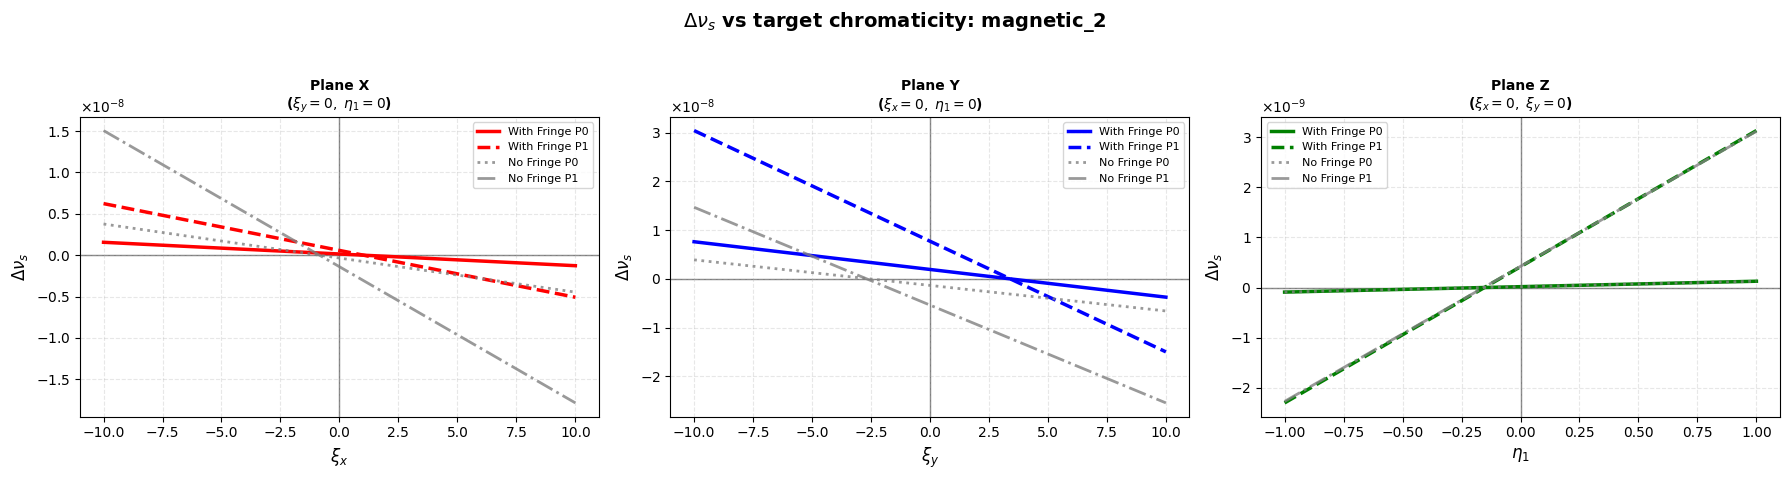

OK: C:\GIT_REPOS\SCT\COSY\src\dat\magnetic_2\plots\magnetic_2_dnu_s_vs_chrom.png


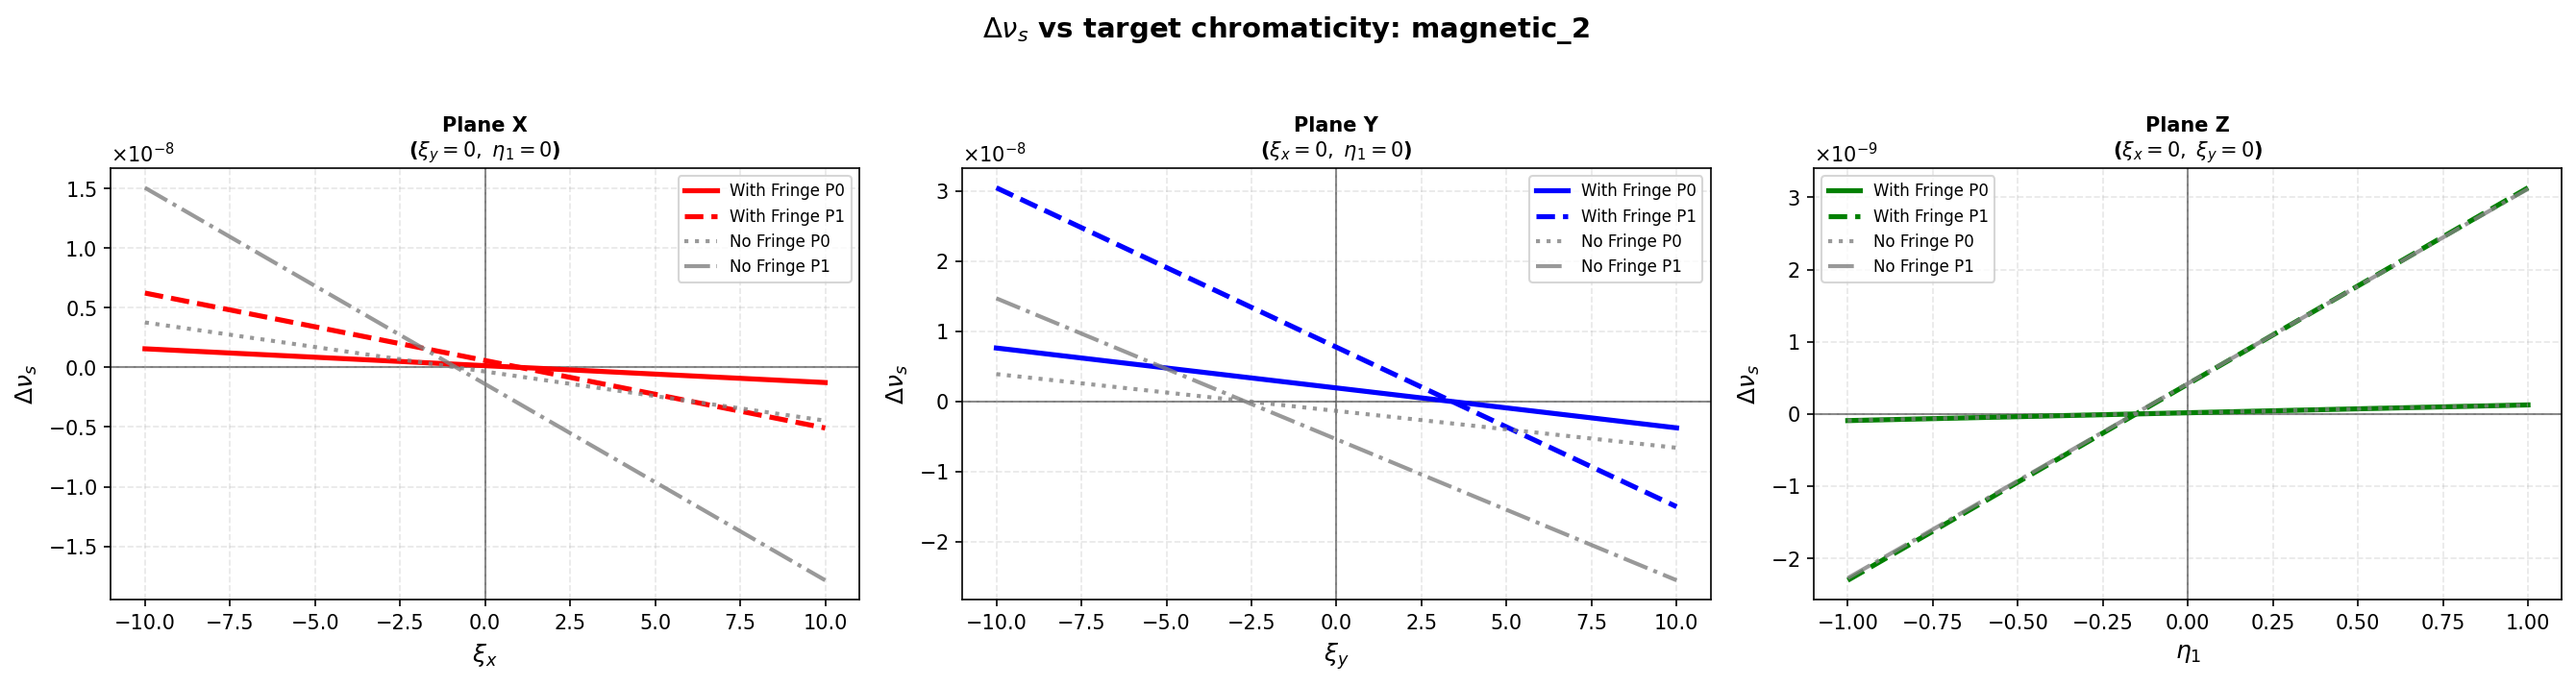

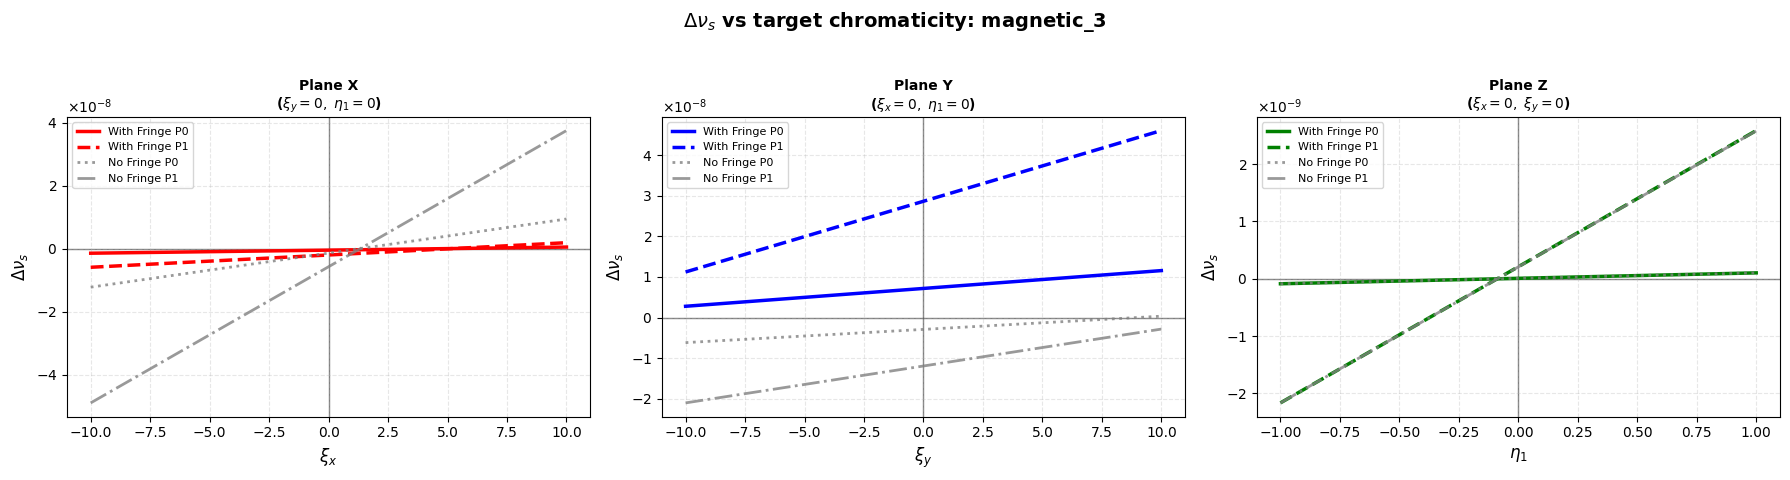

OK: C:\GIT_REPOS\SCT\COSY\src\dat\magnetic_3\plots\magnetic_3_dnu_s_vs_chrom.png


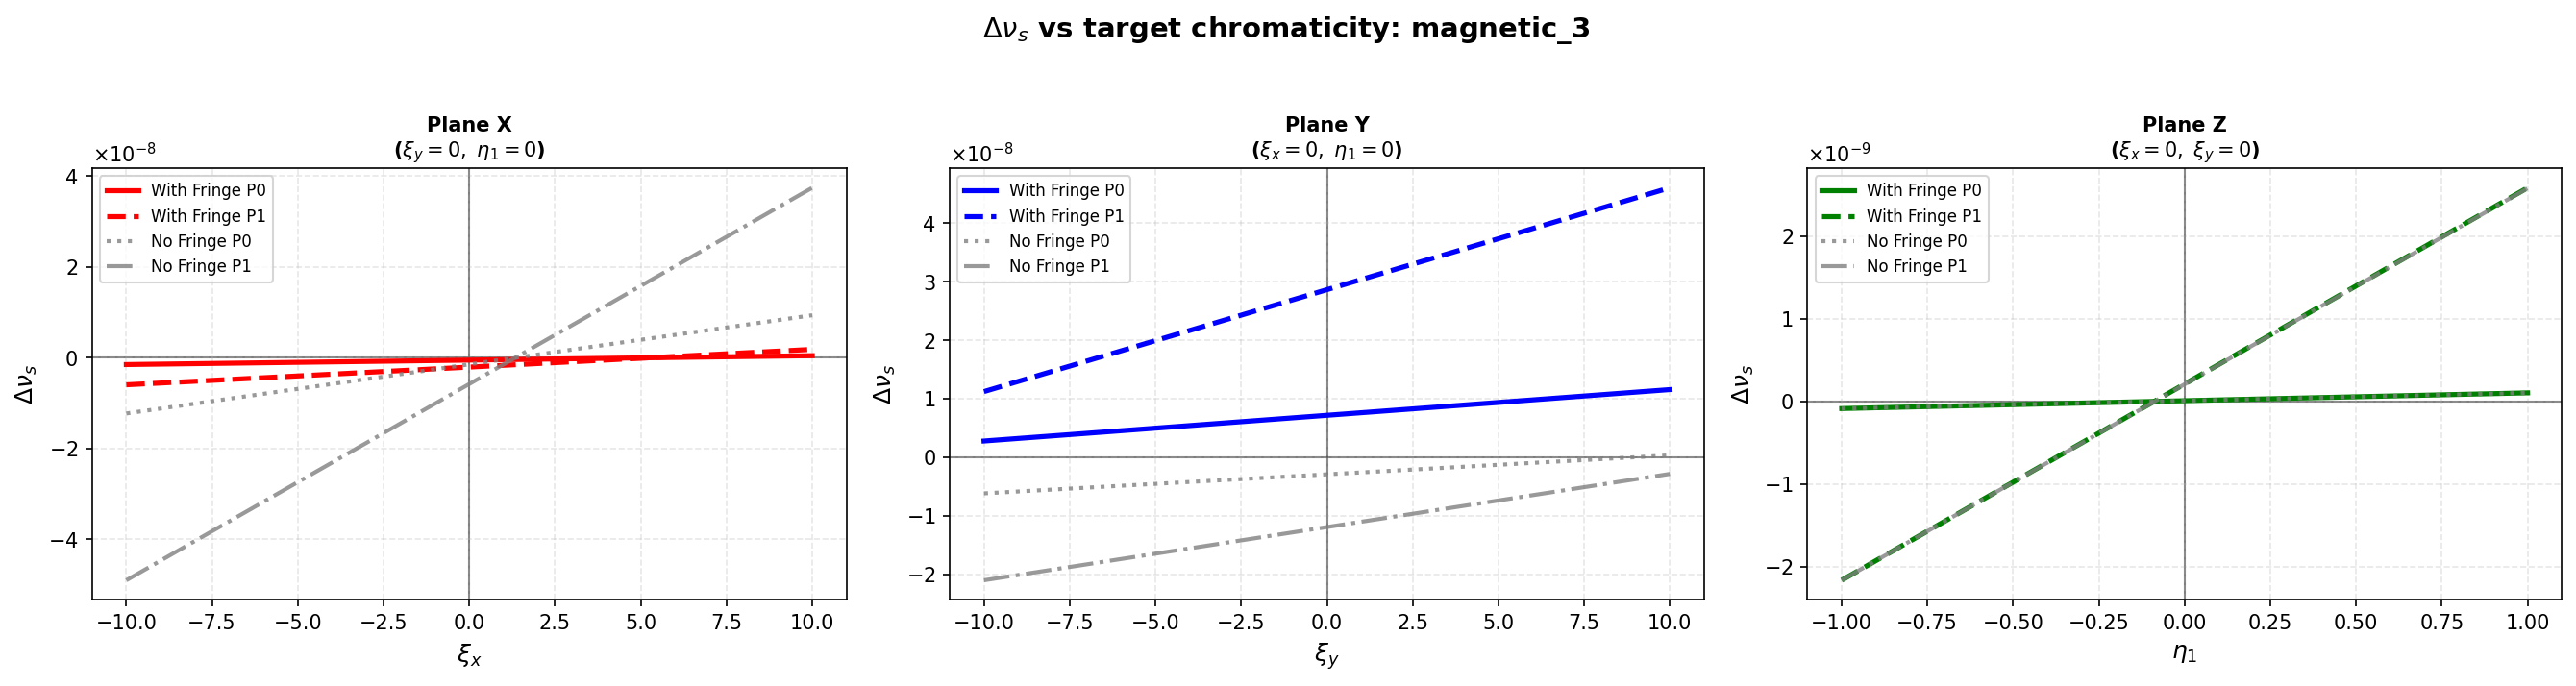

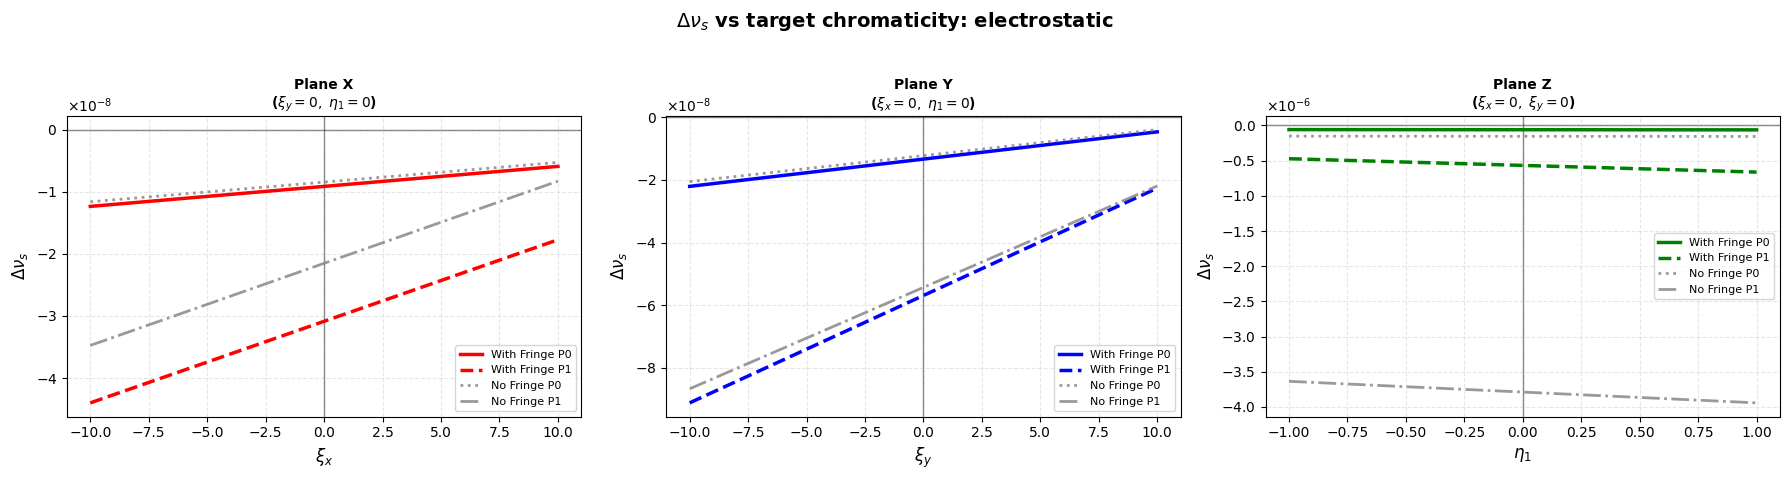

OK: C:\GIT_REPOS\SCT\COSY\src\dat\electrostatic\plots\electrostatic_dnu_s_vs_chrom.png


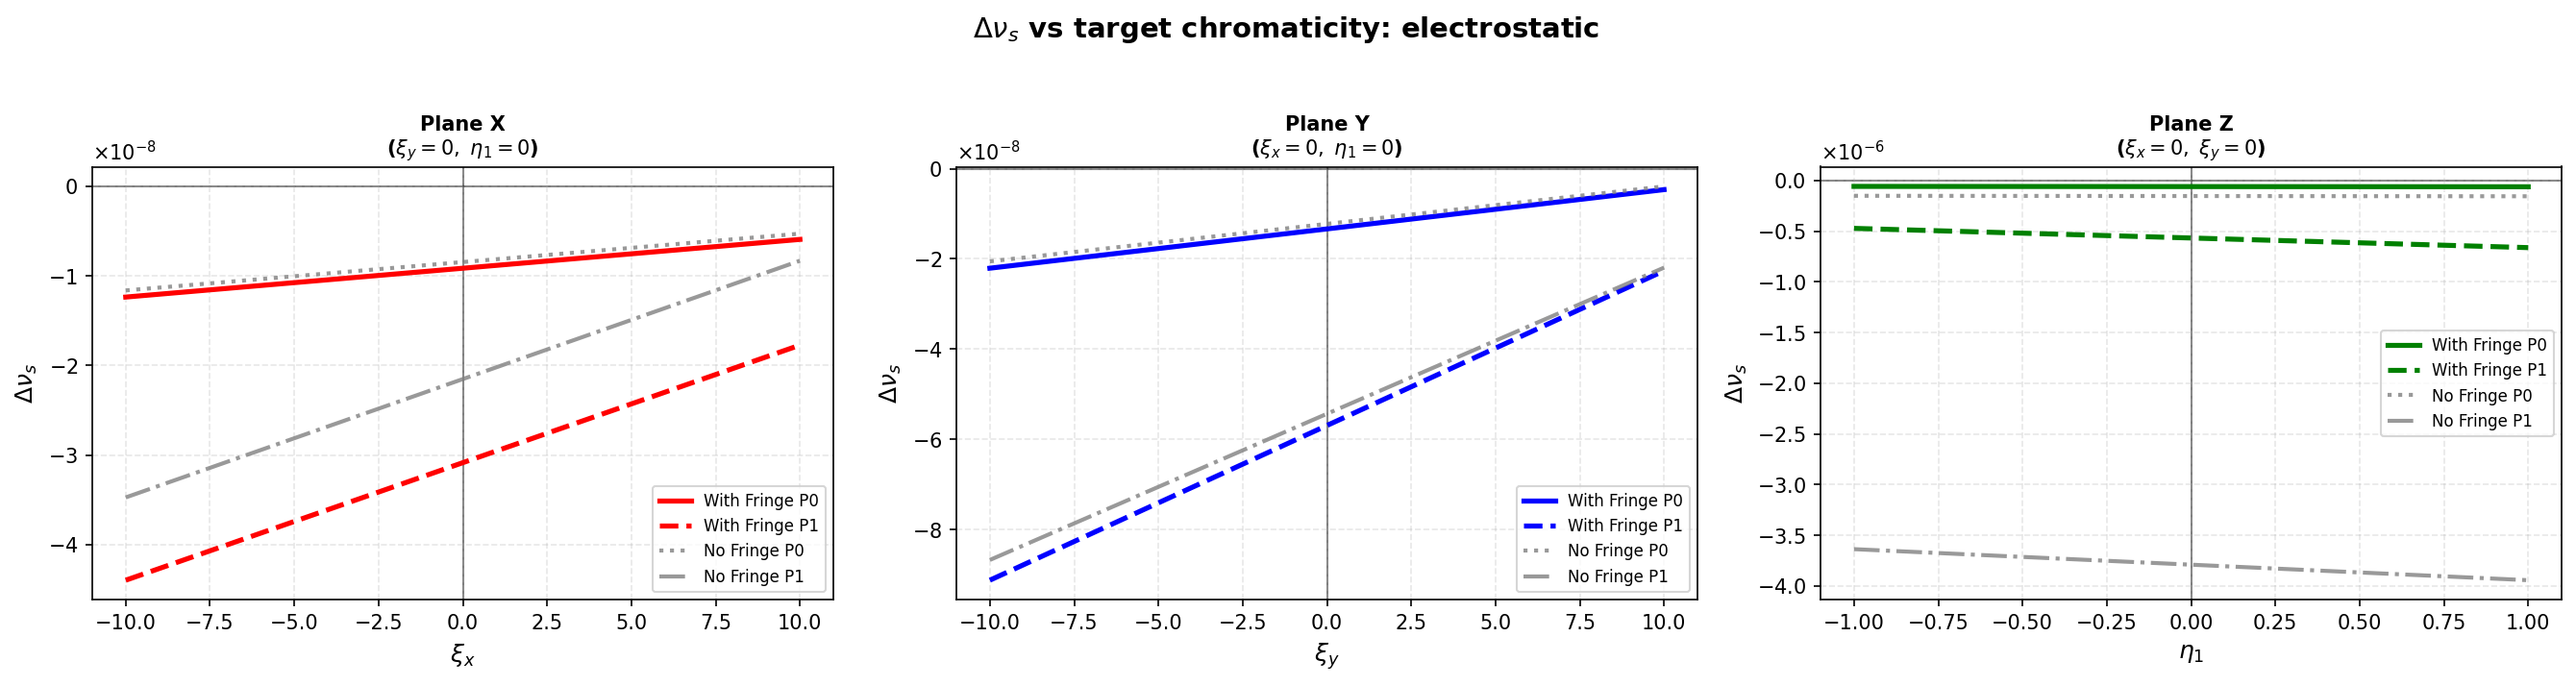

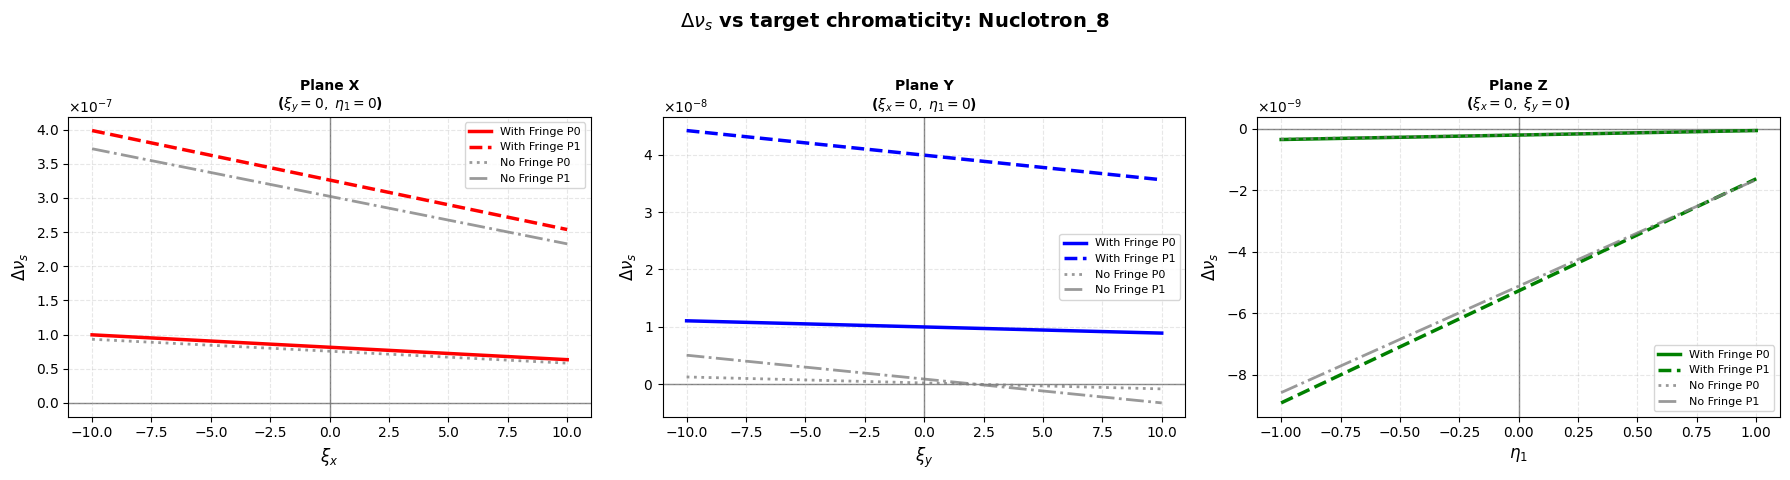

OK: C:\GIT_REPOS\SCT\COSY\src\dat\Nuclotron_8\plots\Nuclotron_8_dnu_s_vs_chrom.png


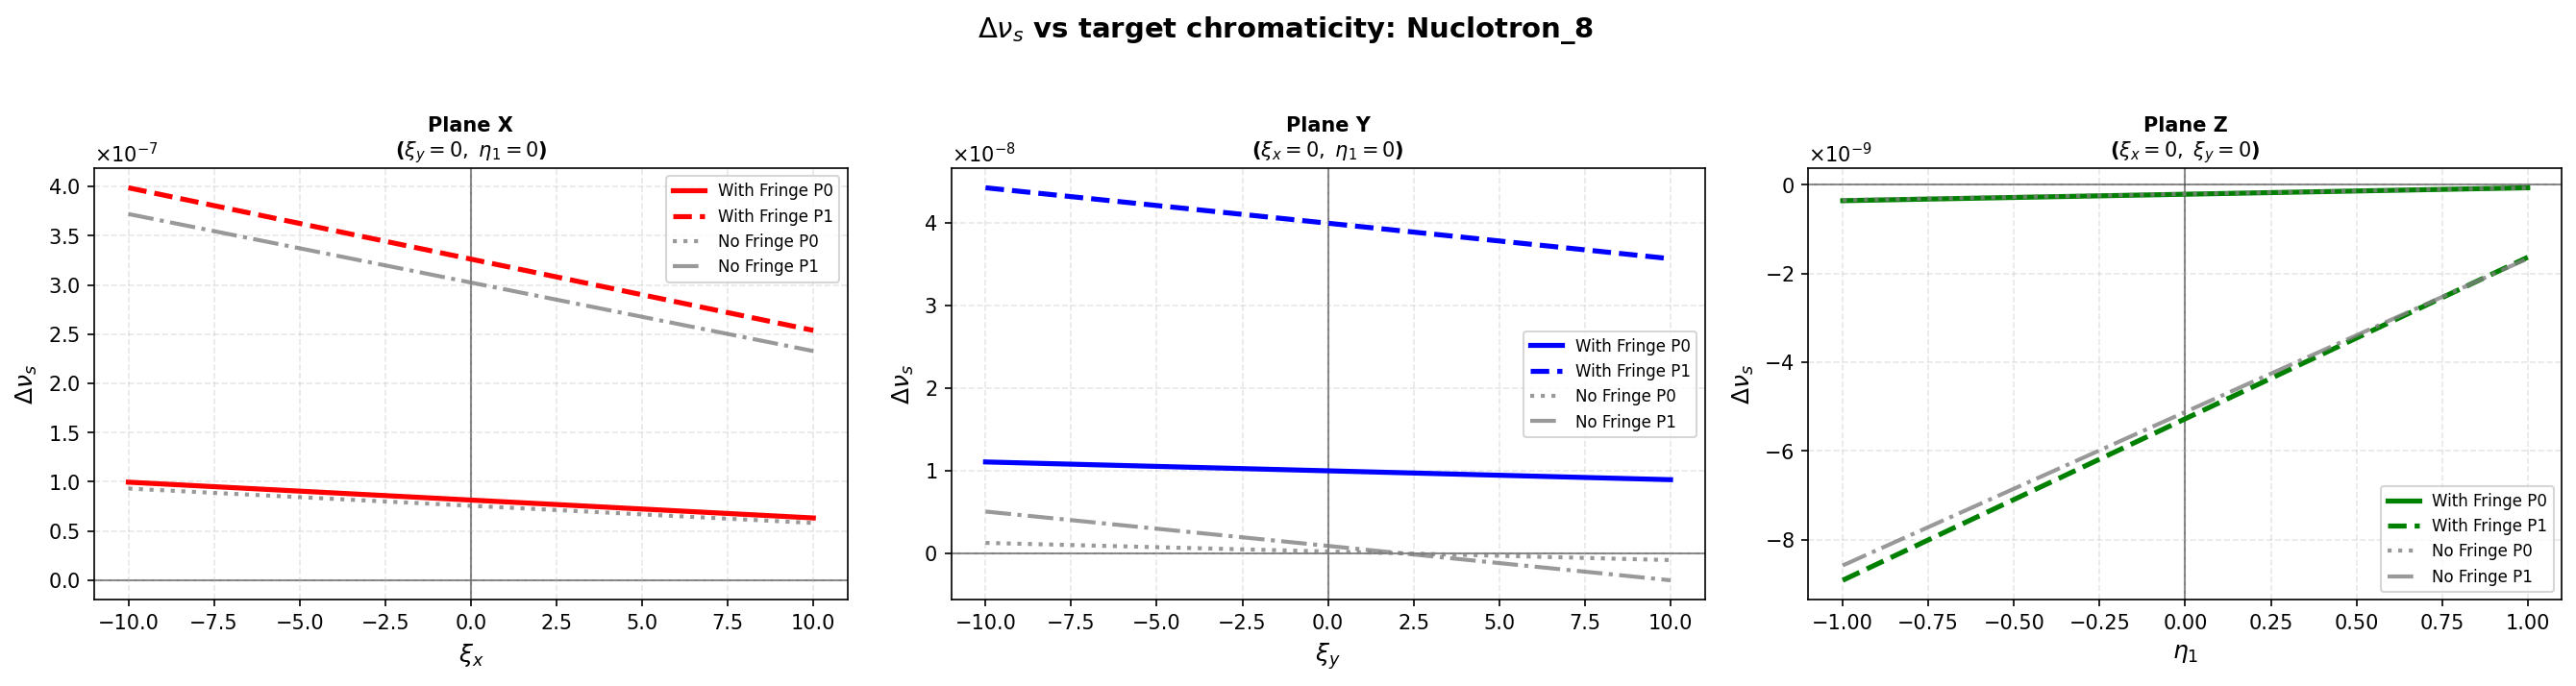

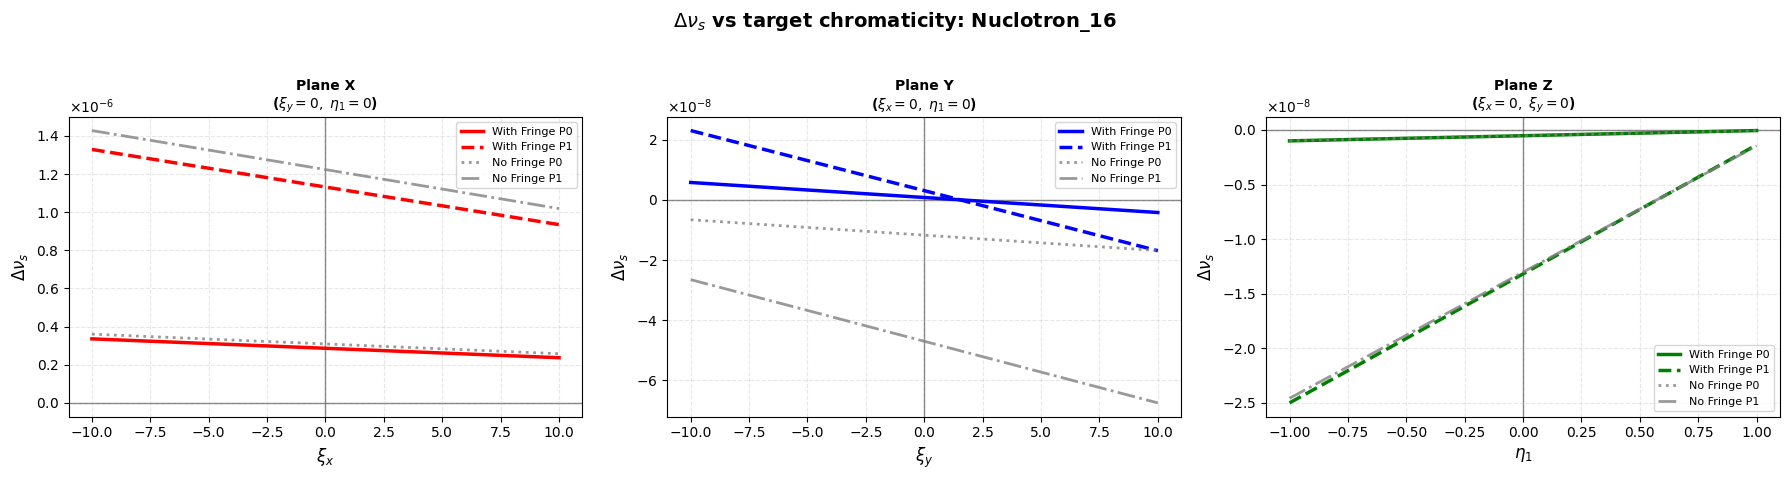

OK: C:\GIT_REPOS\SCT\COSY\src\dat\Nuclotron_16\plots\Nuclotron_16_dnu_s_vs_chrom.png


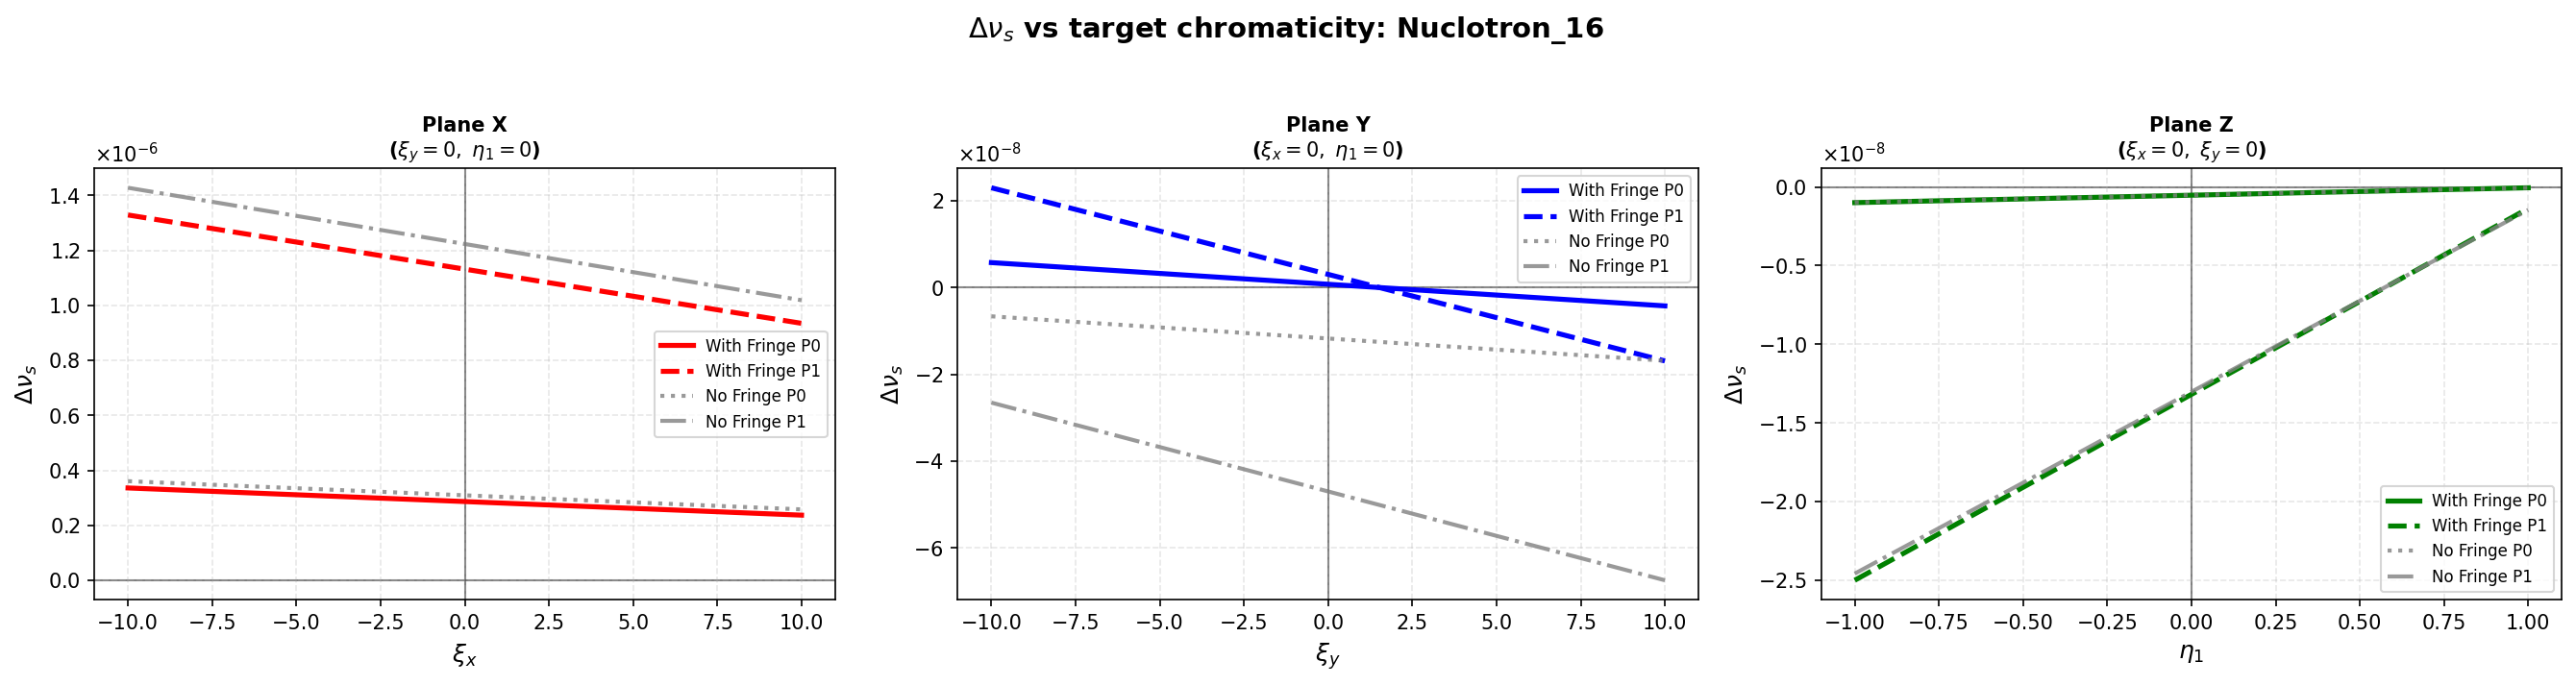

In [33]:
def _style_axes(ax):
    ax.axhline(0, color="black", lw=1.0, alpha=0.5, zorder=0)
    ax.axvline(0, color="black", lw=1.0, alpha=0.5, zorder=0)
    fmt = ScalarFormatter(useMathText=True)
    fmt.set_scientific(True)
    fmt.set_powerlimits((-2, 2))
    ax.yaxis.set_major_formatter(fmt)
    ax.grid(True, linestyle="--", alpha=0.3)


for lat in lattices:
    ok = plot_lattice(lat, root_path, steps=STEPS_DEFAULT, require_fr3=False, show=True)
    if not ok:
        print(f"Skip plots for {lat}")
    else:
        summary = root_path / lat / "plots" / f"{lat}_dnu_s_vs_chrom.png"
        if summary.is_file():
            display(Image(filename=str(summary)))


## Pure Dynamic Response Analysis (Sensitivity Only)

| Component | Total Model (Natural + Dynamic) | Pure Dynamic Model (Slopes Only) |
|-----------|----------------------------------|----------------------------------|
| Chromaticity | $\vec{\xi} = R_{int} I + \xi_{nat}$ | $\vec{\xi}' = R_{int} I$ |
| Spin | $\Delta\nu_s = R_{spin} I + \Delta\nu_{s,nat}$ | $\Delta\nu_s' = R_{spin} I$ |

Zeroing the intercepts isolates the **sensitivity slopes**: how strongly sextupoles couple chromaticity control into spin tune. A flat pure-dynamic curve means weak spin–chrom coupling in that plane.


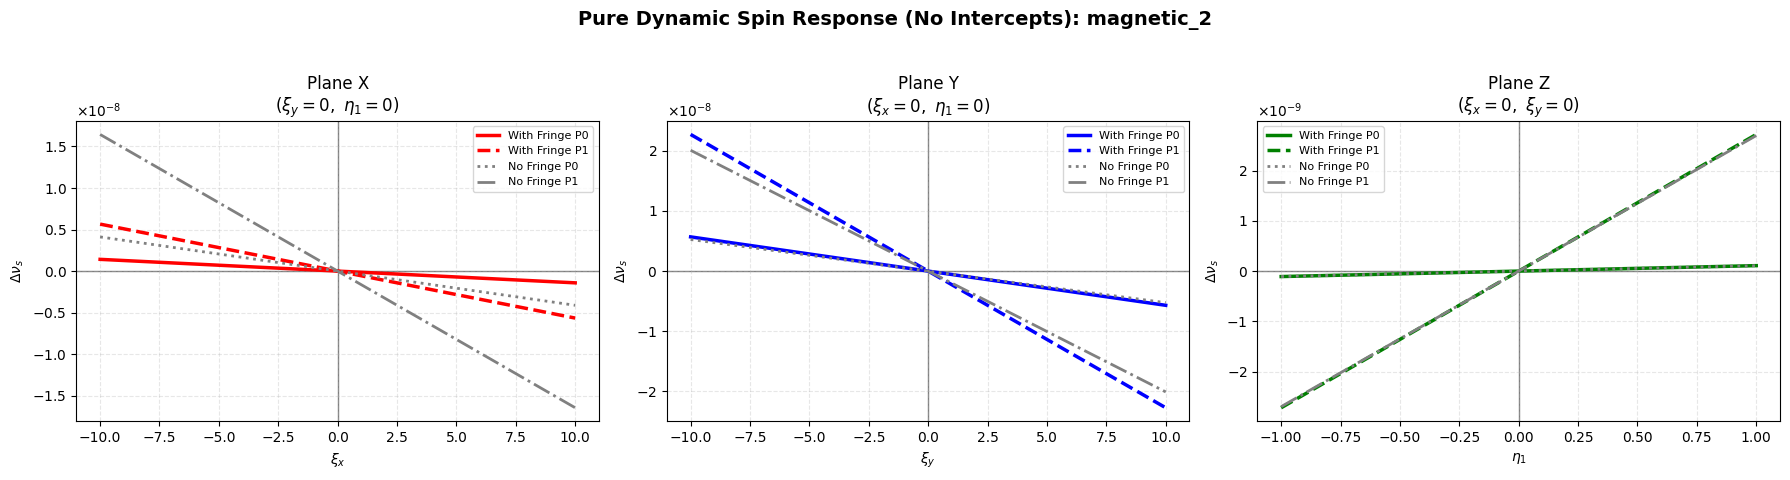

OK: C:\GIT_REPOS\SCT\COSY\src\dat\magnetic_2\plots\magnetic_2_pure_dynamic.png


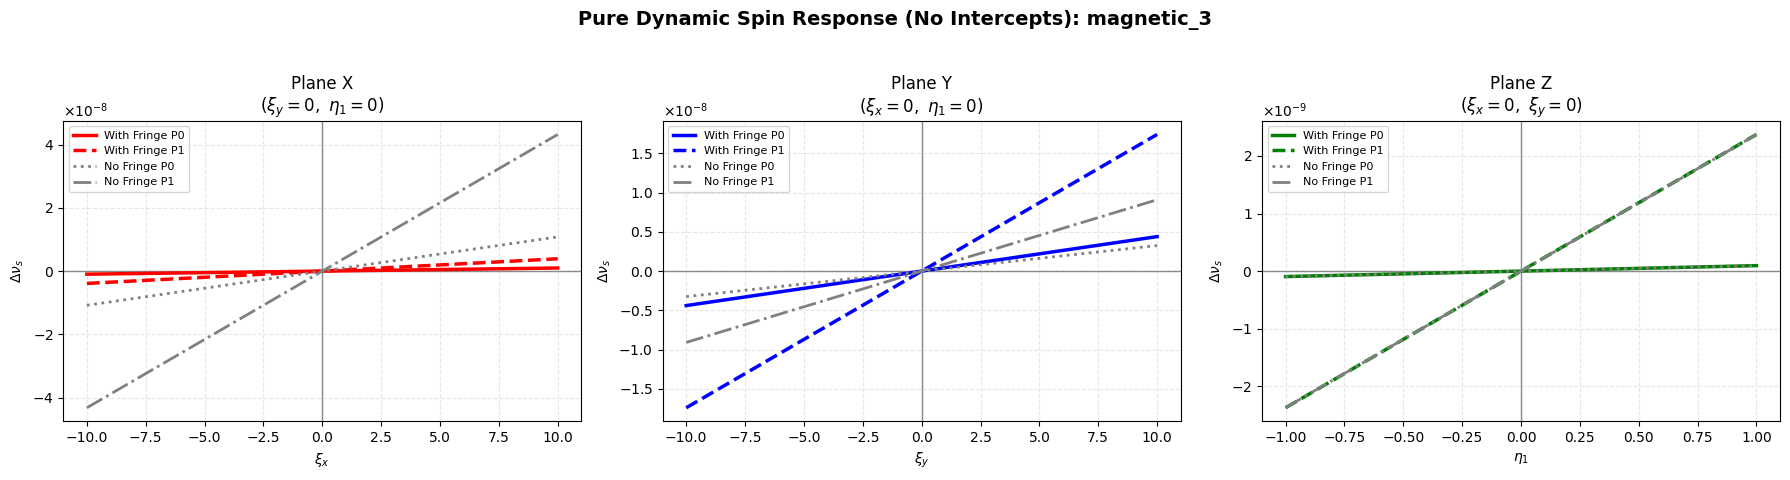

OK: C:\GIT_REPOS\SCT\COSY\src\dat\magnetic_3\plots\magnetic_3_pure_dynamic.png


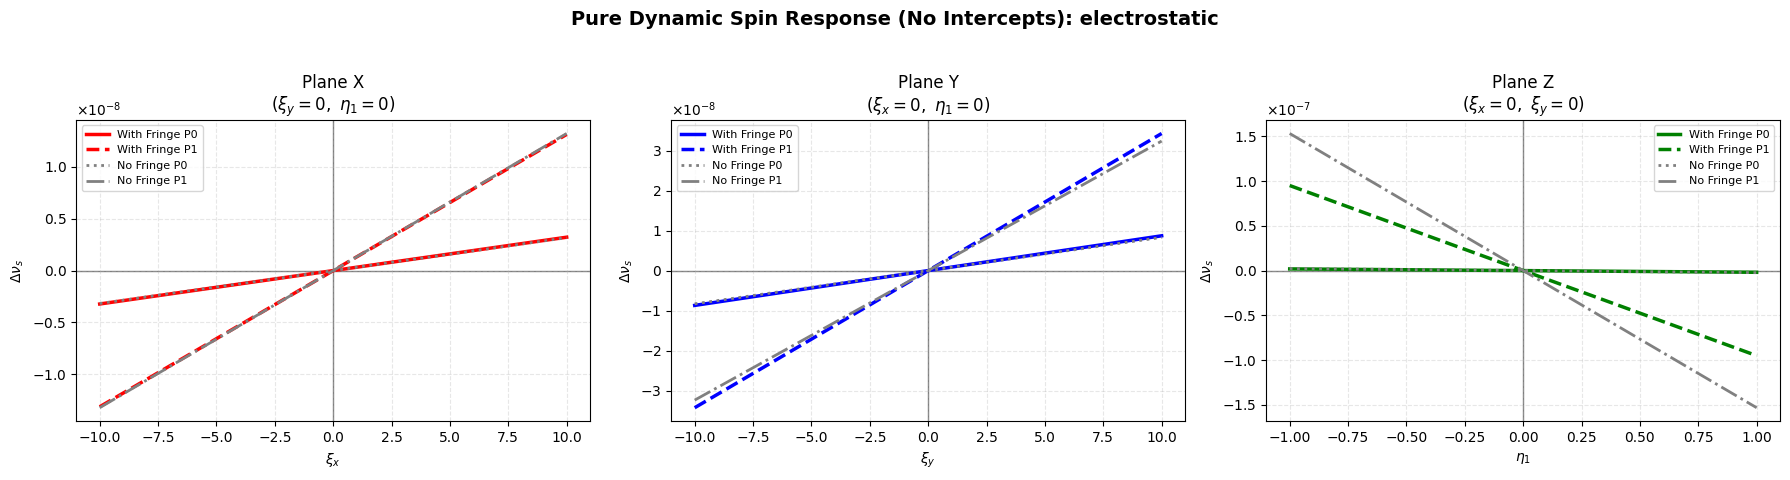

OK: C:\GIT_REPOS\SCT\COSY\src\dat\electrostatic\plots\electrostatic_pure_dynamic.png


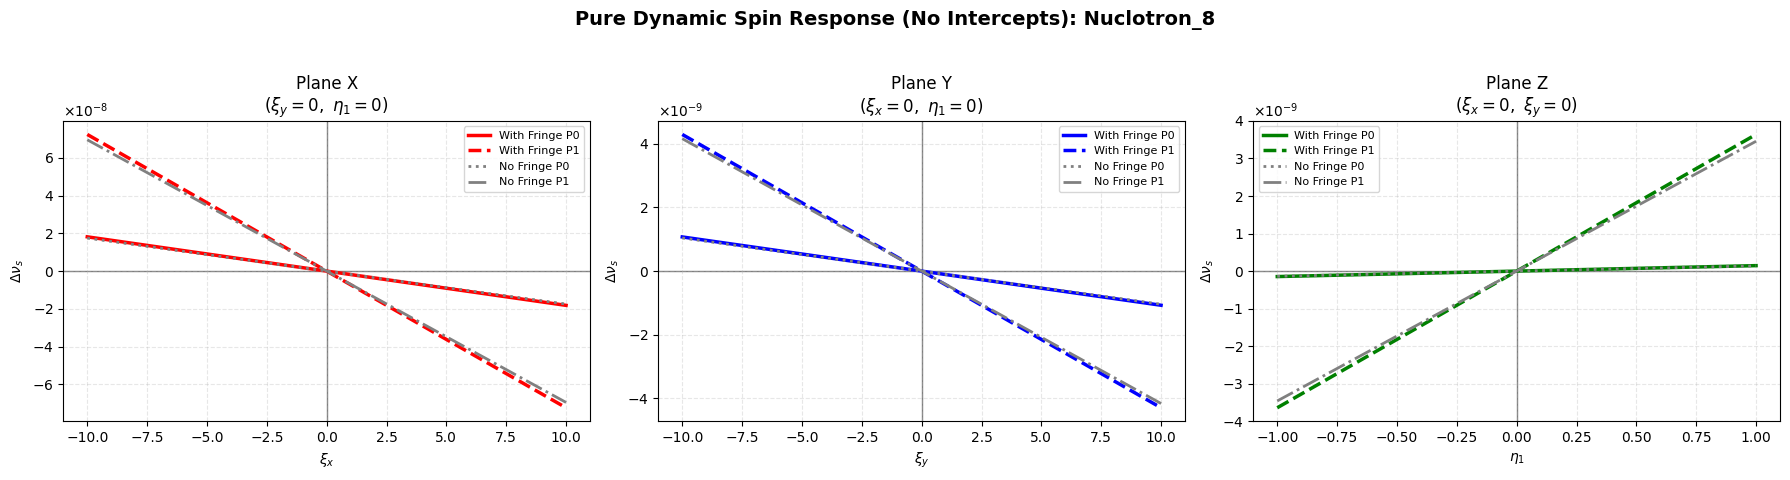

In [ ]:
def plot_pure_dynamic(lat: str, root: Path = root_path, steps: int = STEPS_DEFAULT):
    df_no = get_data(lat, "FR0", root)
    df_fr = get_data(lat, "FR3", root)
    if df_no is None:
        print(f"Skip pure dynamic {lat}: no FR0")
        return
    models = build_lattice_models(df_no, df_fr)
    # Zero intercepts
    for state, m in models.items():
        m = dict(m)
        m["int_nat"] = np.zeros(3)
        m["dnu_s_nat"] = np.zeros(3)
        m["spin_nat"] = np.zeros(3)
        models[state] = m
    ranges, curves = compute_panel_curves(models, standard_chrom_ranges(steps))
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"Pure Dynamic Spin Response (No Intercepts): {lat}", fontsize=14, fontweight="bold")
    out_dir = root / lat / "plots"
    out_dir.mkdir(parents=True, exist_ok=True)
    for i in range(3):
        ax = axes[i]
        color = PANEL_COLORS[i]
        if "WithFr_P0" in models:
            ax.plot(ranges[i], curves["WithFr_P0"][i], color=color, ls="-", lw=2.5, label="With Fringe P0")
            ax.plot(ranges[i], curves["WithFr_P1"][i], color=color, ls="--", lw=2.5, label="With Fringe P1")
        ax.plot(ranges[i], curves["NoFr_P0"][i], color="gray", ls=":", lw=2.0, label="No Fringe P0")
        ax.plot(ranges[i], curves["NoFr_P1"][i], color="gray", ls="-.", lw=2.0, label="No Fringe P1")
        ax.set_xlabel(PANEL_CHROM_LABELS[i])
        ax.set_ylabel(r"$\Delta\nu_s$")
        ax.set_title(f"Plane {PLANE_NAMES[i].upper()}\n({PANEL_CONSTRAINTS[i]})")
        _style_axes(ax)
        ax.legend(fontsize=8)
        t_fig, t_ax = plt.subplots(figsize=(6, 5))
        if "WithFr_P0" in models:
            t_ax.plot(ranges[i], curves["WithFr_P0"][i], color=color, ls="-", lw=2.5, label="With Fringe P0")
            t_ax.plot(ranges[i], curves["WithFr_P1"][i], color=color, ls="--", lw=2.5, label="With Fringe P1")
        t_ax.plot(ranges[i], curves["NoFr_P0"][i], color="gray", ls=":", label="No Fringe P0")
        t_ax.plot(ranges[i], curves["NoFr_P1"][i], color="gray", ls="-.", label="No Fringe P1")
        t_ax.set_xlabel(PANEL_CHROM_LABELS[i])
        t_ax.set_ylabel(r"$\Delta\nu_s$")
        t_ax.set_title(f"{lat} pure dynamic | {PLANE_NAMES[i].upper()}")
        _style_axes(t_ax)
        t_ax.legend(fontsize=8)
        t_fig.savefig(out_dir / f"{lat}_pure_dynamic_{PLANE_NAMES[i]}.png", dpi=300, bbox_inches="tight")
        plt.close(t_fig)
    fig.tight_layout(rect=[0, 0.03, 1, 0.95])
    out = out_dir / f"{lat}_pure_dynamic.png"
    fig.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"OK: {out}")


for lat in lattices:
    plot_pure_dynamic(lat)


## Mathematical Verification of Model Integrity

We verify the chain $\xi \rightarrow I \rightarrow \Delta\nu_s$: for each measured chromaticity triple on the scan grid, invert $R_{int}$ to recover currents, then predict $\Delta\nu_s$ and compare with COSY. High $R^2$ confirms that the linear mapping model is faithful.


In [ ]:
verify_rows = []
for lat in lattices:
    for mode in MODES:
        df = get_data(lat, mode, root_path)
        if df is None:
            continue
        chrom = verify_chrom_model(df)
        print(f"=== {lat} {mode}: chrom linear model ===")
        print(chrom)
        for suffix, tag in [("", "P0"), ("_1", "P1")]:
            link = verify_chrom_to_spin_link(df, suffix=suffix)
            print(f"=== {lat} {mode}: xi -> spin link ({tag}) ===")
            print(link)
            plot_verify_chrom_to_spin(
                lat, mode, df, suffix=suffix, show=False,
                save_dir=root_path / lat / "plots",
            )
            verify_rows.append({
                "lattice": lat, "mode": mode, "particle": tag,
                **{f"r2_{k}": link[f"r2_{k}"] for k in ("x", "y", "z")},
            })
pd.DataFrame(verify_rows)


=== magnetic_2 FR0: chrom linear model ===
{'r2_chrom_x': 1.0, 'max_res_chrom_x': 1.0835776720341528e-12, 'r2_chrom_y': 1.0, 'max_res_chrom_y': 1.0302869668521453e-12, 'r2_eta_1': 1.0, 'max_res_eta_1': 1.432187701766452e-13}
=== magnetic_2 FR0: xi -> spin link (P0) ===
{'r2_x': 0.9999999400136828, 'max_res_x': 4.952920296086662e-13, 'r2_y': 0.9999956862580537, 'max_res_y': 1.348318034995648e-11, 'r2_z': 0.9999999804786304, 'max_res_z': 1.121445158954974e-13}
OK: C:\GIT_REPOS\SCT\COSY\src\dat\magnetic_2\plots\magnetic_2_verify_spin_link_FR0_P0.png
=== magnetic_2 FR0: xi -> spin link (P1) ===
{'r2_x': 0.9999997600195252, 'max_res_x': 3.962174810465961e-12, 'r2_y': 0.9999828143047269, 'max_res_y': 1.0786548476623008e-10, 'r2_z': 0.9999995130798802, 'max_res_z': 1.401703619843338e-11}
OK: C:\GIT_REPOS\SCT\COSY\src\dat\magnetic_2\plots\magnetic_2_verify_spin_link_FR0_P1.png
=== magnetic_2 FR3: chrom linear model ===
{'r2_chrom_x': 1.0, 'max_res_chrom_x': 9.17056830473939e-09, 'r2_chrom_y': 

,lattice,mode,particle,r2_x,r2_y,r2_z
0,magnetic_2,FR0,P0,1.000000,0.999996,1.000000
1,magnetic_2,FR0,P1,1.000000,0.999983,1.000000
2,magnetic_2,FR3,P0,1.000000,0.999999,1.000000
3,magnetic_2,FR3,P1,1.000000,0.999995,1.000000
4,magnetic_3,FR0,P0,1.000000,0.999966,1.000000
5,magnetic_3,FR0,P1,0.999999,0.999864,1.000000
6,magnetic_3,FR3,P0,1.000000,0.999996,1.000000
7,magnetic_3,FR3,P1,1.000000,0.999986,1.000000
8,electrostatic,FR0,P0,1.000000,1.000000,1.000000
9,electrostatic,FR0,P1,1.000000,1.000000,1.000000


## Zero Chromaticity Working Point

Solve $\vec{I}^* = R_{int}^{-1}(-\vec{\xi}_{nat})$ so that $\xi_x=\xi_y=\eta_1=0$, then evaluate

$$\Delta\vec{\nu}_s^* = R_{spin}\,\vec{I}^* + \Delta\vec{\nu}_{s,nat}.$$

If $\Delta\nu_s^*\approx 0$ in all planes, the mapping method **simultaneously** achieves zero chromaticity and suppresses spin decoherence. A large residual $\Delta\nu_s^*$ means chromaticity nulling alone is not sufficient for SCT.


,lattice,mode,particle,SGx1*,SGx2*,SGy1*,dnu_x*,dnu_y*,dnu_z*,cond,xi_nat_x,xi_nat_y,eta1_nat
0,magnetic_2,FR0,P0,0.004111,-0.003184,-0.004031,-3.488869e-10,-1.338758e-09,1.692355e-11,34.538178,-1.840801,-1.847679,1.017794
1,magnetic_2,FR0,P1,0.004111,-0.003184,-0.004031,-1.394950e-09,-5.381132e-09,4.227020e-10,34.538178,-1.840801,-1.847679,1.017794
2,magnetic_2,FR3,P0,0.003674,-0.002249,-0.002876,1.436927e-10,1.936333e-09,1.666365e-11,6.475463,-1.713754,-1.538274,1.019388
3,magnetic_2,FR3,P1,0.003674,-0.002249,-0.002876,5.748848e-10,7.736357e-09,4.147109e-10,6.475463,-1.713754,-1.538274,1.019388
4,magnetic_3,FR0,P0,0.027590,-0.028351,-0.023078,-1.446347e-09,-2.902894e-09,8.333193e-12,35.874824,-3.735648,-3.745471,1.022233
5,magnetic_3,FR0,P1,0.027590,-0.028351,-0.023078,-5.778696e-09,-1.191030e-08,2.076899e-10,35.874824,-3.735648,-3.745471,1.022233
6,magnetic_3,FR3,P0,0.022568,-0.015349,-0.012611,-5.128391e-10,7.177115e-09,8.447900e-12,17.128099,-3.461790,-3.679293,1.024467
7,magnetic_3,FR3,P1,0.022568,-0.015349,-0.012611,-2.049541e-09,2.863198e-08,2.107848e-10,17.128099,-3.461790,-3.679293,1.024467
8,electrostatic,FR0,P0,-0.216969,13.890952,-9.517714,-8.451842e-09,-1.223934e-08,-1.546071e-07,47.512242,-9.170757,-8.816105,1.066057
9,electrostatic,FR0,P1,-0.216969,13.890952,-9.517714,-2.152521e-08,-5.430406e-08,-3.788229e-06,47.512242,-9.170757,-8.816105,1.066057


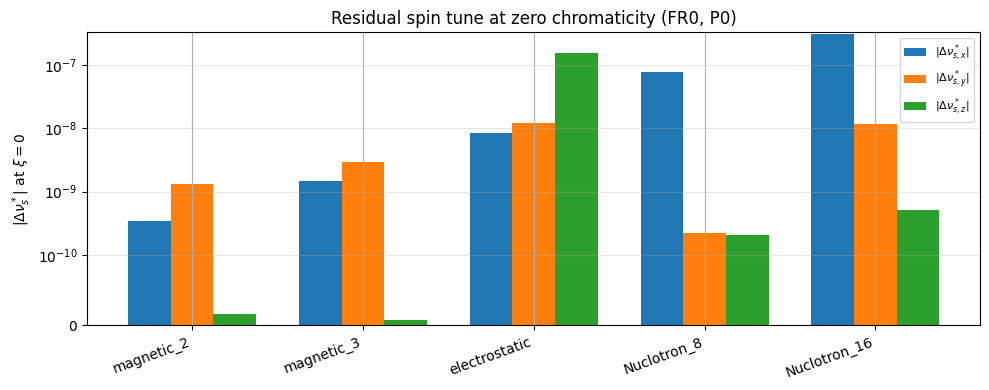

OK: C:\GIT_REPOS\SCT\COSY\src\dat\presentation_dnu_star_FR0_P0.png


In [ ]:
wp_rows = []
for lat in lattices:
    for mode in MODES:
        df = get_data(lat, mode, root_path)
        if df is None:
            continue
        for suffix, tag in [("", "P0"), ("_1", "P1")]:
            m = get_dual_model(df, suffix=suffix)
            wp = zero_chrom_working_point(m)
            wp_rows.append({
                "lattice": lat,
                "mode": mode,
                "particle": tag,
                "SGx1*": wp["I_star"][0],
                "SGx2*": wp["I_star"][1],
                "SGy1*": wp["I_star"][2],
                "dnu_x*": wp["dnu_s_star"][0],
                "dnu_y*": wp["dnu_s_star"][1],
                "dnu_z*": wp["dnu_s_star"][2],
                "cond": wp["cond_R_int"],
                "xi_nat_x": wp["xi_nat"][0],
                "xi_nat_y": wp["xi_nat"][1],
                "eta1_nat": wp["xi_nat"][2],
            })

wp_df = pd.DataFrame(wp_rows)
display(wp_df)

# Bar chart: |dnu_s*| at I* for FR0 P0
sub = wp_df[(wp_df["mode"] == "FR0") & (wp_df["particle"] == "P0")]
if len(sub):
    fig, ax = plt.subplots(figsize=(10, 4))
    x = np.arange(len(sub))
    w = 0.25
    ax.bar(x - w, sub["dnu_x*"].abs(), w, label=r"$|\Delta\nu_{s,x}^*|$")
    ax.bar(x, sub["dnu_y*"].abs(), w, label=r"$|\Delta\nu_{s,y}^*|$")
    ax.bar(x + w, sub["dnu_z*"].abs(), w, label=r"$|\Delta\nu_{s,z}^*|$")
    ax.set_xticks(x)
    ax.set_xticklabels(sub["lattice"], rotation=20, ha="right")
    ax.set_ylabel(r"$|\Delta\nu_s^*|$ at $\xi=0$")
    ax.set_title("Residual spin tune at zero chromaticity (FR0, P0)")
    ax.set_yscale("symlog", linthresh=1e-10)
    ax.legend(fontsize=8)
    ax.grid(True, axis="y", alpha=0.3)
    fig.tight_layout()
    out = root_path / "presentation_dnu_star_FR0_P0.png"
    fig.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"OK: {out}")


## Class Comparison Overlay

Overlay one representative of each class — magnetic (`magnetic_2`), electrostatic, combined (`Nuclotron_8`) — on the three independent-control panels (FR0 P0).


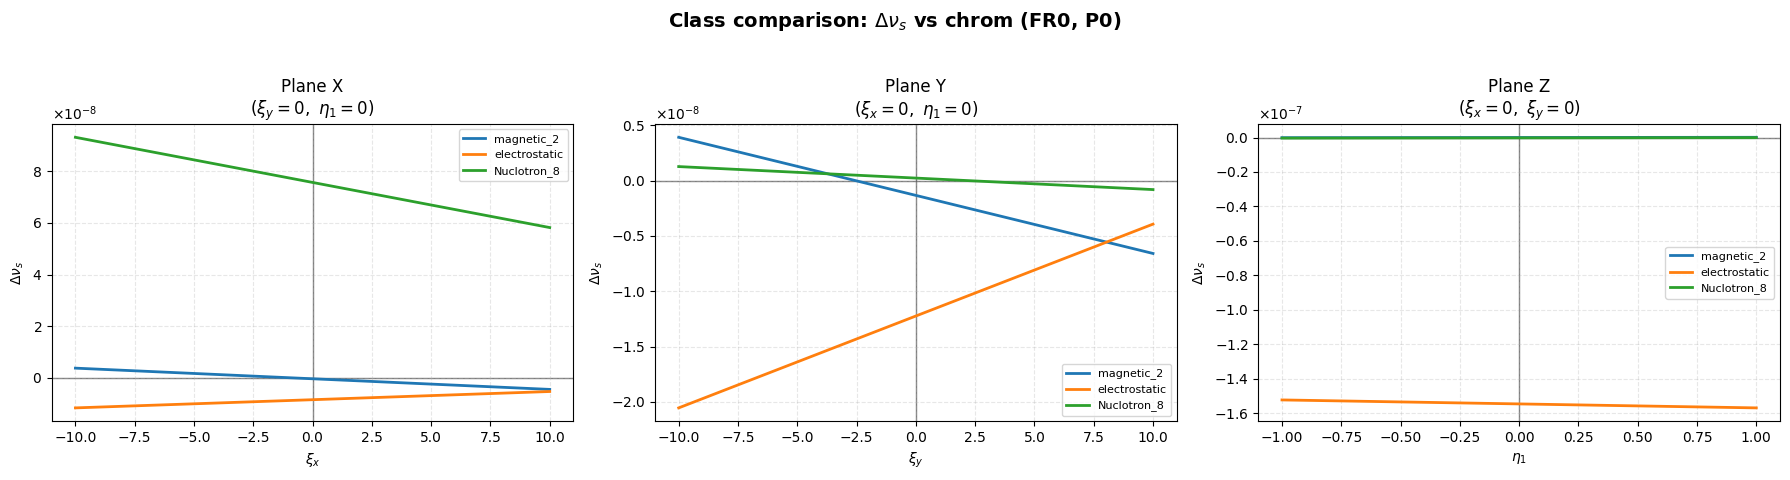

OK: C:\GIT_REPOS\SCT\COSY\src\dat\presentation_class_overlay_FR0.png


In [ ]:
compare = ["magnetic_2", "electrostatic", "Nuclotron_8"]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(r"Class comparison: $\Delta\nu_s$ vs chrom (FR0, P0)", fontsize=14, fontweight="bold")
cmap = {"magnetic_2": "C0", "electrostatic": "C1", "Nuclotron_8": "C2"}

for lat in compare:
    df0 = get_data(lat, "FR0", root_path)
    if df0 is None:
        continue
    models = build_lattice_models(df0, None)
    ranges, curves = compute_panel_curves(models, standard_chrom_ranges())
    for i in range(3):
        axes[i].plot(ranges[i], curves["NoFr_P0"][i], color=cmap[lat], lw=2.0, label=lat)

for i, ax in enumerate(axes):
    ax.set_xlabel(PANEL_CHROM_LABELS[i])
    ax.set_ylabel(r"$\Delta\nu_s$")
    ax.set_title(f"Plane {PLANE_NAMES[i].upper()}\n({PANEL_CONSTRAINTS[i]})")
    _style_axes(ax)
    ax.legend(fontsize=8)

fig.tight_layout(rect=[0, 0.03, 1, 0.95])
out = root_path / "presentation_class_overlay_FR0.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"OK: {out}")


## Magnetic series `magnetic_3` … `magnetic_8`

Separate block for the **pure-magnetic** family with increasing superperiodicity ($N=3\ldots 8$). For each lattice:

1. Twiss ($\beta_x$, $\beta_y$, $D_x$) and floor-plan layout
2. Independent-control $\Delta\nu_s(\xi_x)$, $\Delta\nu_s(\xi_y)$, $\Delta\nu_s(\eta_1)$ — FR0 / FR3, P0 / P1
3. Zero-chromaticity working point $I^*$ and residual $\Delta\nu_s^*$

Mapping data: `COSY/src/dat/magnetic_N/` (already computed for FR0 and FR3).


In [ ]:
from map_lat_lib import MAGNETIC_SERIES_3_8

magnetic_series = list(MAGNETIC_SERIES_3_8)  # magnetic_3 .. magnetic_8
print("Magnetic series:", magnetic_series)


ImportError: cannot import name 'MAGNETIC_SERIES_3_8' from 'map_lat_lib' (c:\GIT_REPOS\SCT\COSY\analysis\map_lat_lib.py)

### Twiss and layout (`magnetic_3`…`magnetic_8`)


In [ ]:
db = default_lattice_db()
for lat in magnetic_series:
    twiss_png, layout_png = plot_and_save_lattice(lat, config=db[lat], show=False)
    print(lat)
    display(Image(filename=str(twiss_png)))
    display(Image(filename=str(layout_png)))


### $\Delta\nu_s$ vs chromaticity — independent control

Same Map_lat methodology: invert $R_{int}$ at target $\xi$ with the other two chrom components held at zero.


In [ ]:
for lat in magnetic_series:
    ok = plot_lattice(lat, root_path, steps=STEPS_DEFAULT, require_fr3=False, show=True)
    if not ok:
        print(f"Skip plots for {lat}")
    else:
        summary = root_path / lat / "plots" / f"{lat}_dnu_s_vs_chrom.png"
        if summary.is_file():
            display(Image(filename=str(summary)))


### Overlay: magnetic series slopes (FR0, P0)

Compare how $\Delta\nu_s$ responds across $N=3\ldots 8$ on the three independent-control panels.


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(r"Magnetic series $N=3\ldots 8$: $\Delta\nu_s$ vs chrom (FR0, P0)", fontsize=14, fontweight="bold")
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(magnetic_series)))

for lat, color in zip(magnetic_series, colors):
    df0 = get_data(lat, "FR0", root_path)
    if df0 is None:
        print(f"Skip overlay {lat}: no FR0")
        continue
    models = build_lattice_models(df0, None)
    ranges, curves = compute_panel_curves(models, standard_chrom_ranges())
    for i in range(3):
        axes[i].plot(ranges[i], curves["NoFr_P0"][i], color=color, lw=2.0, label=lat)

for i, ax in enumerate(axes):
    ax.set_xlabel(PANEL_CHROM_LABELS[i])
    ax.set_ylabel(r"$\Delta\nu_s$")
    ax.set_title(f"Plane {PLANE_NAMES[i].upper()}\n({PANEL_CONSTRAINTS[i]})")
    _style_axes(ax)
    ax.legend(fontsize=8)

fig.tight_layout(rect=[0, 0.03, 1, 0.95])
out = root_path / "presentation_magnetic_3_8_overlay_FR0.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"OK: {out}")


### Zero chromaticity $I^*$ and residual $\Delta\nu_s^*$ (`magnetic_3`…`8`)


In [ ]:
mag_wp_rows = []
for lat in magnetic_series:
    for mode in MODES:
        df = get_data(lat, mode, root_path)
        if df is None:
            continue
        for suffix, tag in [("", "P0"), ("_1", "P1")]:
            m = get_dual_model(df, suffix=suffix)
            wp = zero_chrom_working_point(m)
            mag_wp_rows.append({
                "lattice": lat,
                "mode": mode,
                "particle": tag,
                "SGx1*": wp["I_star"][0],
                "SGx2*": wp["I_star"][1],
                "SGy1*": wp["I_star"][2],
                "dnu_x*": wp["dnu_s_star"][0],
                "dnu_y*": wp["dnu_s_star"][1],
                "dnu_z*": wp["dnu_s_star"][2],
                "cond": wp["cond_R_int"],
            })

mag_wp_df = pd.DataFrame(mag_wp_rows)
display(mag_wp_df)

sub = mag_wp_df[(mag_wp_df["mode"] == "FR0") & (mag_wp_df["particle"] == "P0")]
if len(sub):
    fig, ax = plt.subplots(figsize=(10, 4))
    x = np.arange(len(sub))
    w = 0.25
    ax.bar(x - w, sub["dnu_x*"].abs(), w, label=r"$|\Delta\nu_{s,x}^*|$")
    ax.bar(x, sub["dnu_y*"].abs(), w, label=r"$|\Delta\nu_{s,y}^*|$")
    ax.bar(x + w, sub["dnu_z*"].abs(), w, label=r"$|\Delta\nu_{s,z}^*|$")
    ax.set_xticks(x)
    ax.set_xticklabels(sub["lattice"], rotation=20, ha="right")
    ax.set_ylabel(r"$|\Delta\nu_s^*|$ at $\xi=0$")
    ax.set_title(r"Residual spin tune at zero chromaticity — magnetic $N=3\ldots 8$ (FR0, P0)")
    ax.set_yscale("symlog", linthresh=1e-10)
    ax.legend(fontsize=8)
    ax.grid(True, axis="y", alpha=0.3)
    fig.tight_layout()
    out = root_path / "presentation_magnetic_3_8_dnu_star_FR0_P0.png"
    fig.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"OK: {out}")
